파트1: 탐색적 데이터 분석(EDA):

1) 특징 분석.

2) 여러 특징을 고려하여 관계나 추세를 찾는 것.

파트2: 기능 엔지니어링 및 데이터 정제:

1) 몇 가지 기능을 추가합니다.

2) 중복된 기능을 제거합니다.

3) 특징을 모델링을 위한 적절한 형태로 변환합니다.

파트3: 예측 모델링

1) 기본 알고리즘 실행.

2) 교차 검증.

3) 조립.

4) 중요 기능 추출.

<br>

##**파트 1. 탐색적 데이터 분석 (EDA)**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
data=pd.read_csv('/content/train-2.csv')

In [4]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data.isnull().sum() #checking for total null values

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Age, Cabin, Embarked는 값이 Null.

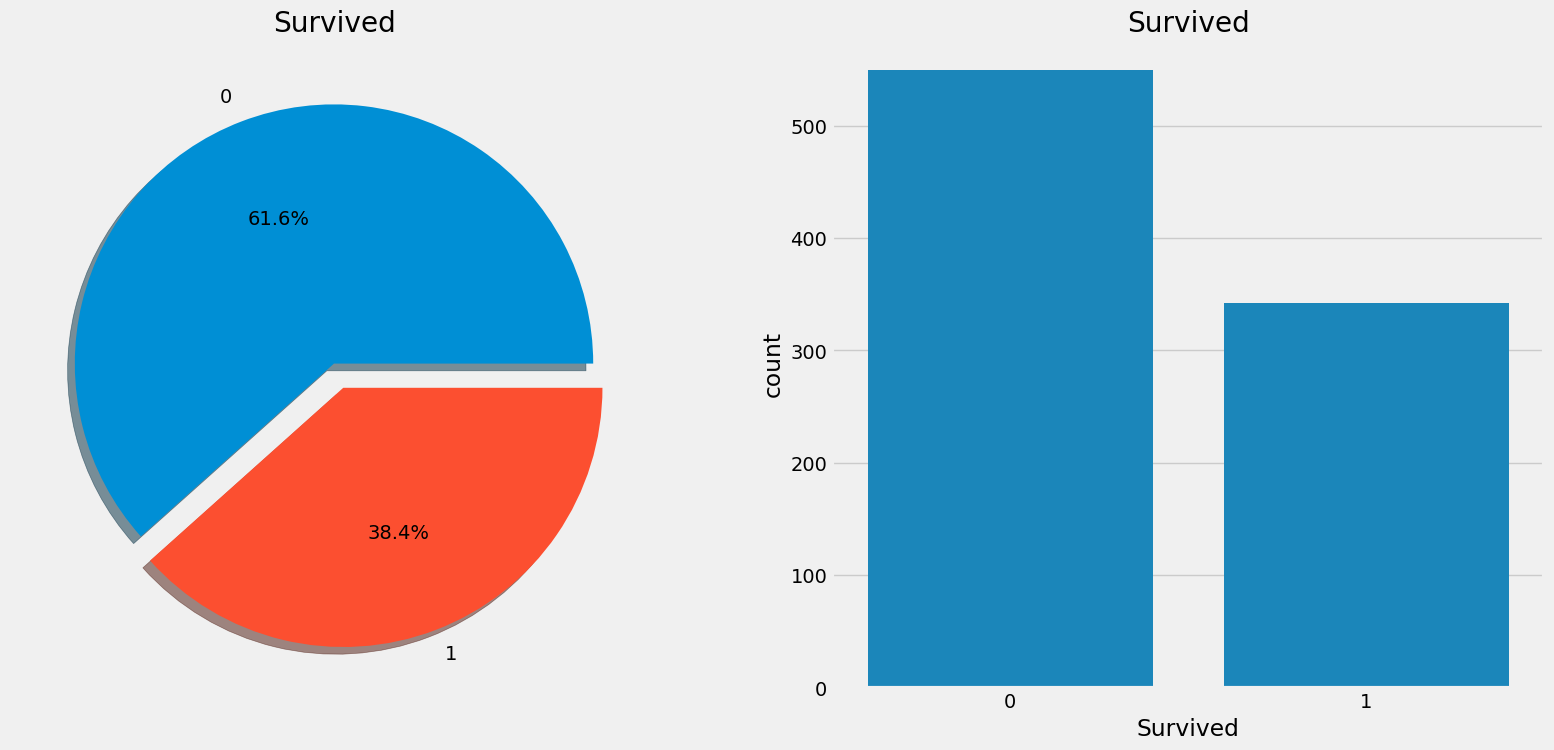

In [6]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data['Survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Survived')
ax[0].set_ylabel('')
sns.countplot(x='Survived',data=data,ax=ax[1])
ax[1].set_title('Survived')
plt.show()

사고에서 살아남은 승객이 많지 않음.

탑승한 891명의 승객 중 약 350명만 살아남았으며, 즉 단지 38.4%만이 사고에서 살아남음.

<br>

###**기능 유형**

**범주형 특징:**

두 개 이상의 범주를 가지고 해당 특성의 각 값을 해당 범주별로 분류할 수 있는 경우.

변수들 정렬 및 순서 부여 불가능하기 때문에, 이들을 또한 명목 변수라고도 부름

**서수 특징:**

범주형 값과 유사하지만, 그 차이점은 값들 사이에 상대적인 순서나 정렬을 가질 수 있다는 점.

변수에 대해 상대적인 정렬을 할 수 있음

**연속 기능:**

피처는 두 점 사이 또는 features 열의 최소값 또는 최대값 사이에서 값을 취할 수 있는 경우 연속이라고 함.

<br>

###**기능 분석**

**성별 -> 범주형 기능**


In [7]:
data.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

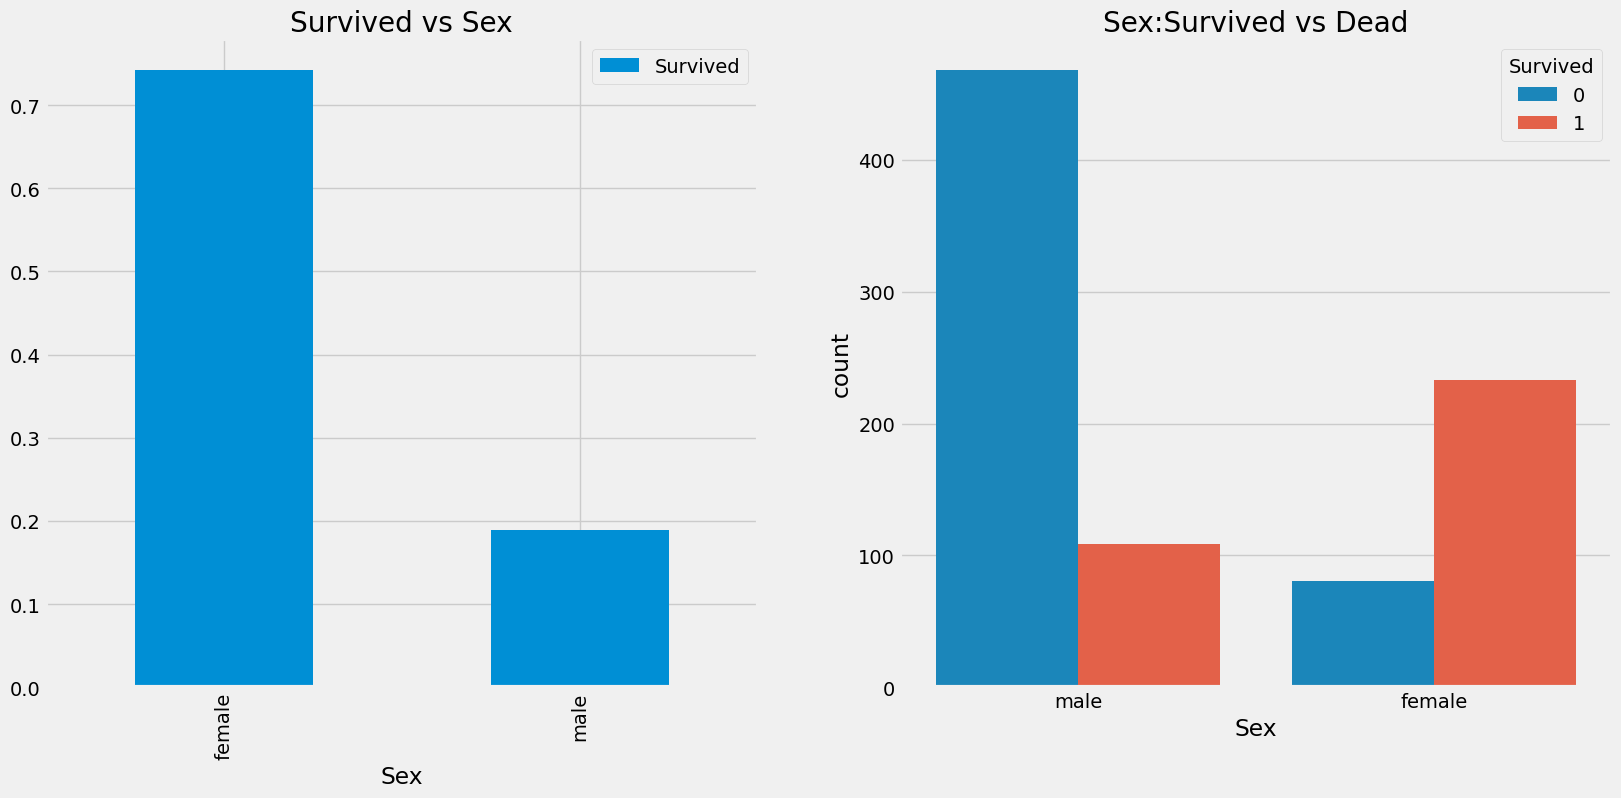

In [8]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data[['Sex','Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
sns.countplot(x='Sex',hue='Survived',data=data,ax=ax[1])
ax[1].set_title('Sex:Survived vs Dead')
plt.show()

남성 수는 여성 수보다 훨씬 많음. 그럼에도 불구하고 구출된 여성 수는 남성 구출 수의 거의 두 배에 달함. 선박에 탑승한 여성의 생존율은 약 75%이며, 남성의 생존율은 약 18~19%.

<br>

**Pclass -> 서수 특징**

In [9]:
pd.crosstab(data.Pclass,data.Survived,margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


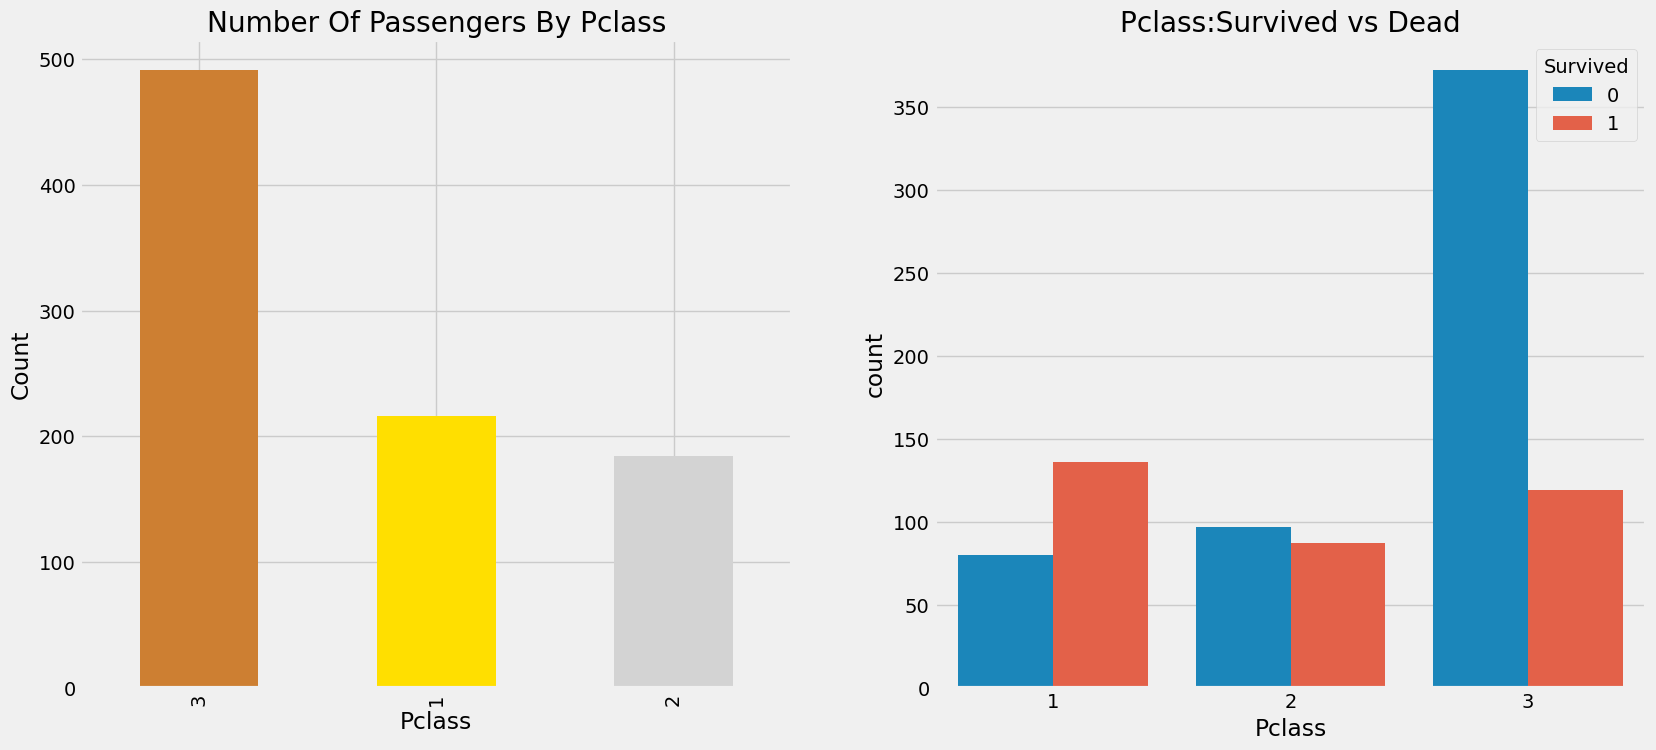

In [10]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data['Pclass'].value_counts().plot.bar(color=['#CD7F32','#FFDF00','#D3D3D3'],ax=ax[0])
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
sns.countplot(x='Pclass',hue='Survived',data=data,ax=ax[1])
ax[1].set_title('Pclass:Survived vs Dead')
plt.show()

1등석 승객들이 구조 과정에서 매우 높은 우선순위를 받았다는 것을 확인할 수 있음. 3등석 승객 수가 훨씬 많았음에도 불구하고, 이들의 생존률은 약 25%로 매우 낮음.

즉, 돈과 사회적 지위가 영향을 미쳤다고 볼 수 있음

In [11]:
pd.crosstab([data.Sex,data.Survived],data.Pclass,margins=True).style.background_gradient(cmap='summer_r')

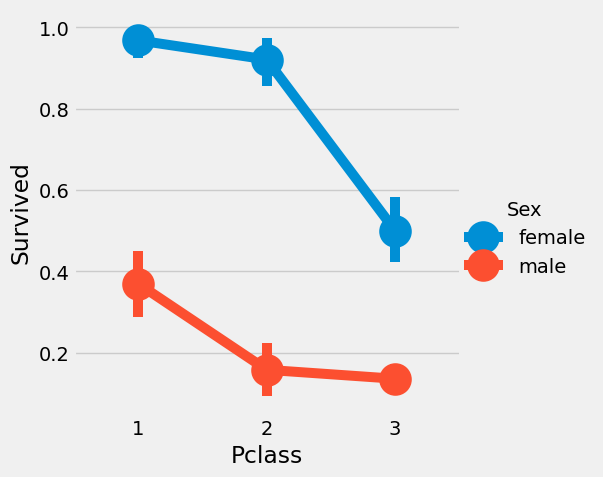

In [12]:
sns.catplot(x='Pclass',y='Survived',hue='Sex',data=data,kind='point')
plt.show()

범주형 값들을 쉽게 구분해주기 때문에 FactorPlot을 사용.

1등석 여성의 생존률이 약 95~96%임을 알 수 있음. (이는 1등석 여성 94명 중 단 3명만 사망)

객실 등급과 관계 없이 여성들이 구조 과정에서 가장 먼저 우선순위를 받았다는 점이 분명히 드러남. 반면 1등석 남성조차도 생존률이 매우 낮음

<br>

**Age -> 연속형 변수**

In [13]:
print('Oldest Passenger was of:',data['Age'].max(),'Years')
print('Youngest Passenger was of:',data['Age'].min(),'Years')
print('Average Age on the ship:',data['Age'].mean(),'Years')

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.42 Years
Average Age on the ship: 29.69911764705882 Years


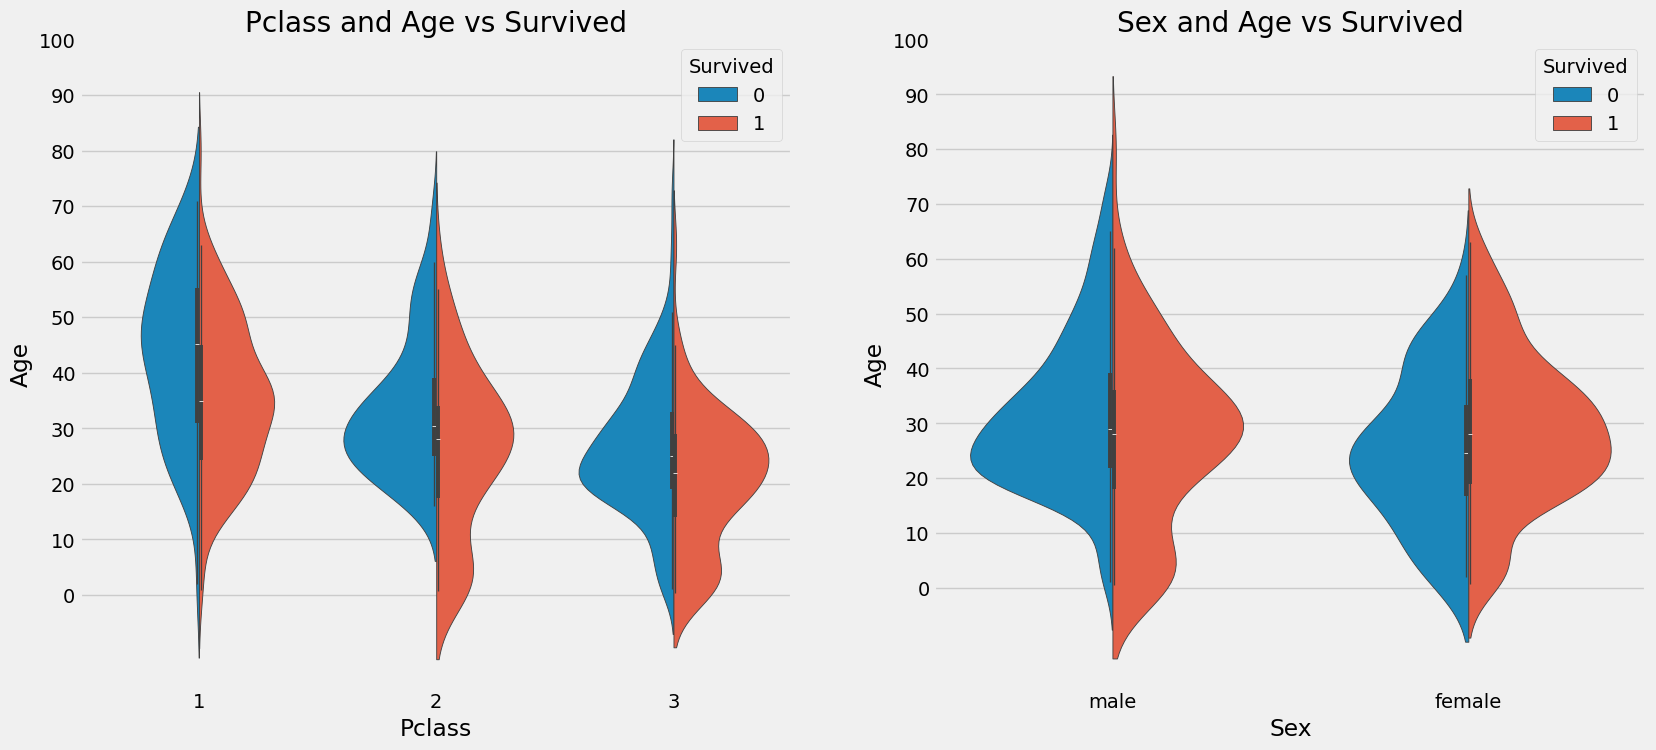

In [14]:
f,ax=plt.subplots(1,2,figsize=(18,8))
sns.violinplot(x="Pclass",y="Age", hue="Survived", data=data,split=True,ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0,110,10))
sns.violinplot(x="Sex",y="Age", hue="Survived", data=data,split=True,ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0,110,10))
plt.show()

관찰 결과 (Observations):
1. 어린이의 수는 객실 등급(Pclass)이 낮아질수록(= 3등석으로 갈수록) 증가하며, 10세 이하 승객(즉, 어린이)의 생존률은 객실 등급과 관계없이 전반적으로 높은 편.
2. 20~50세 승객의 경우, 1등석(Pclass 1)에서 생존 확률이 높으며 특히 여성일수록 더 높음.
3. 남성의 경우에는 나이가 증가할수록 생존 확률이 감소하는 경향이 있음.

In [15]:
data['Initial']=0
for i in data:
    data['Initial']=data.Name.str.extract('([A-Za-z]+)\.') #lets extract the Salutations

여기서는 정규표현식(Regex) [A-Za-z]+\\.를 사용. 이 표현식이 하는 일은 A-Z 또는 a-z 범위의 문자들이 하나 이상([A-Za-z]+) 나오고, 그 뒤에 마침표(.)가 붙은 문자열을 찾는 것.

즉, 이름(Name)에서 “Mr.”, “Mrs.”, “Miss.” 같은 형태를 찾아내는 역할을 함.

In [16]:
pd.crosstab(data.Initial,data.Sex).T.style.background_gradient(cmap='summer_r') #Checking the Initials with the Sex

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


일부 호칭(Initials)에는 Mlle나 Mme처럼 다르게 쓰인(또는 변형된) 형태가 있음. 이들은 모두 Miss를 의미하므로, 이를 Miss로 통일

In [17]:
data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)

In [18]:
data.groupby('Initial')['Age'].mean() #lets check the average age by Initials

,Age
Initial,
Master,4.574167
Miss,21.860000
Mr,32.739609
Mrs,35.981818
Other,45.888889


**NaN Ages 채우기**

In [19]:
## Assigning the NaN Values with the Ceil values of the mean ages
data.loc[(data.Age.isnull())&(data.Initial=='Mr'),'Age']=33
data.loc[(data.Age.isnull())&(data.Initial=='Mrs'),'Age']=36
data.loc[(data.Age.isnull())&(data.Initial=='Master'),'Age']=5
data.loc[(data.Age.isnull())&(data.Initial=='Miss'),'Age']=22
data.loc[(data.Age.isnull())&(data.Initial=='Other'),'Age']=46

In [20]:
data.Age.isnull().any() #So no null values left finally

np.False_

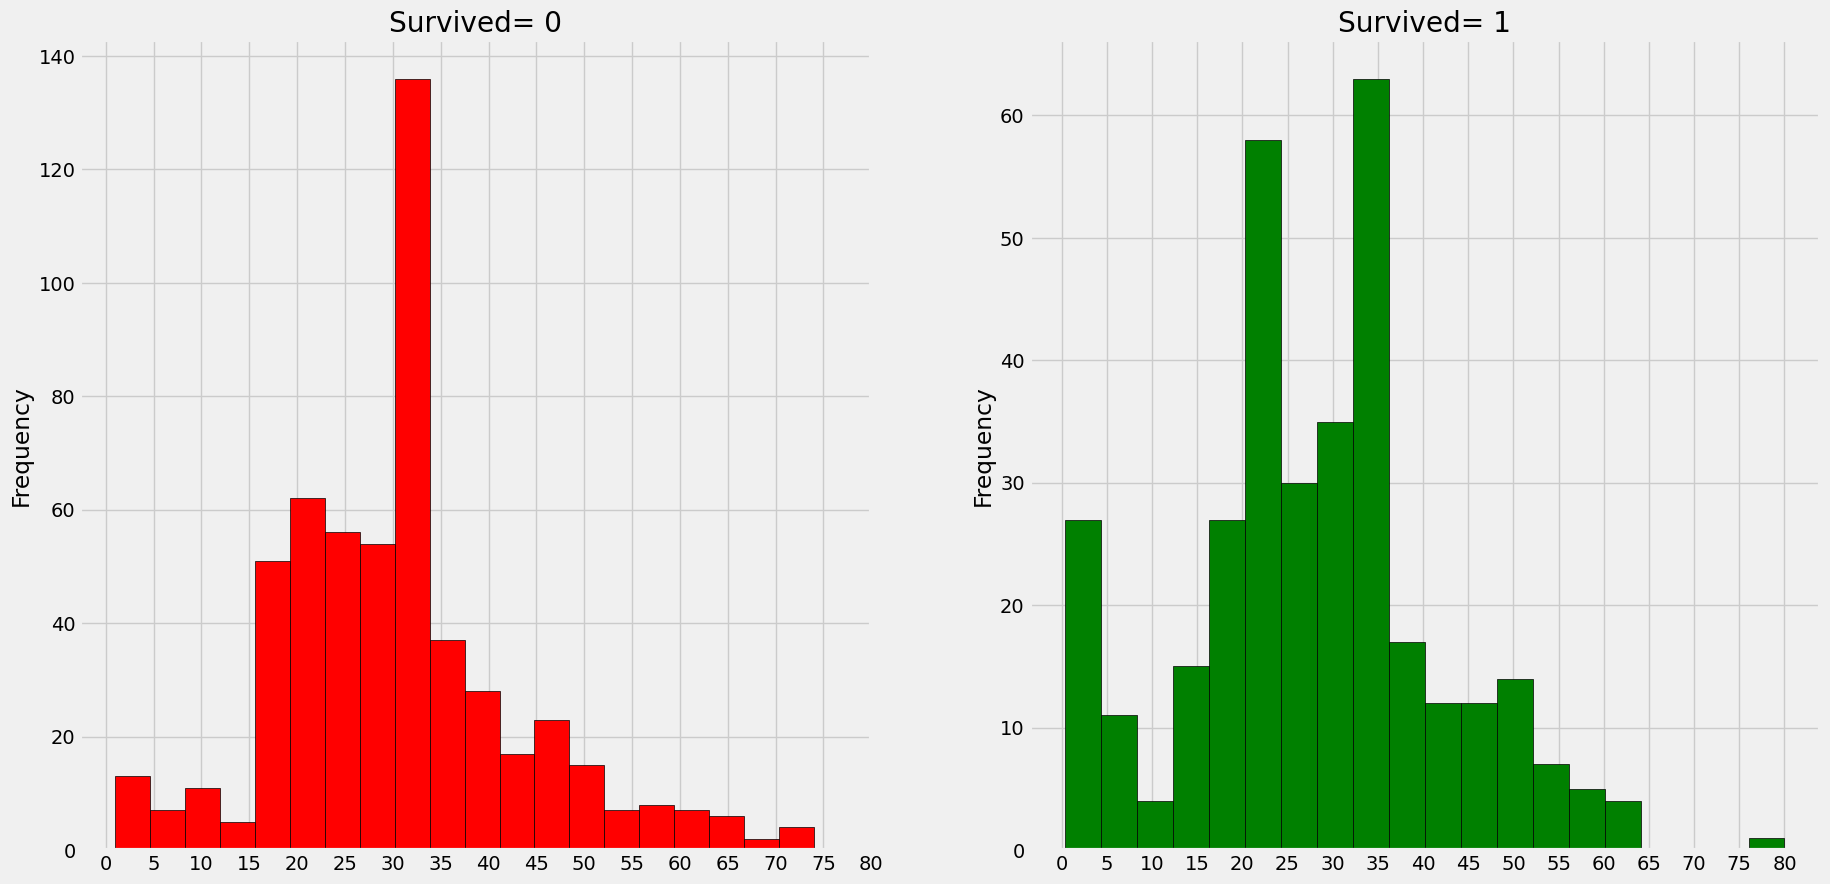

In [21]:
f,ax=plt.subplots(1,2,figsize=(20,10))
data[data['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
data[data['Survived']==1].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

관찰 결과 (Observations):
1. 유아(나이 5세 미만)는 많이 구조됨. (여성과 어린이를 우선으로 구조하는 정책의 영향)
2. 최고령 승객(80세)도 생존.
3. 사망자는 30~40세 연령대에서 가장 많이 발생.

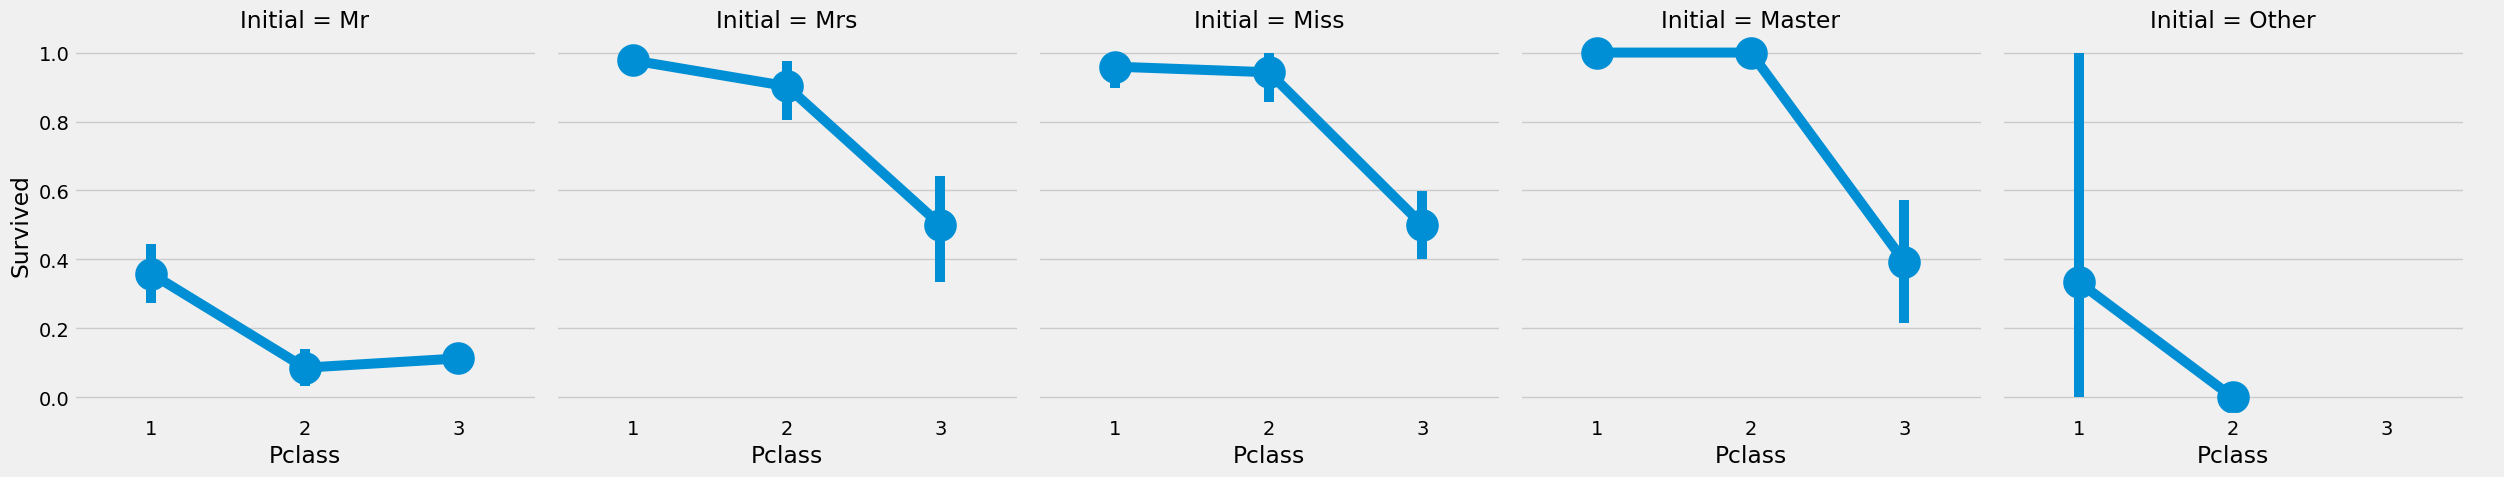

In [25]:
sns.catplot(x='Pclass',y='Survived',col='Initial',data=data,kind='point')
plt.show()

따라서 “여성과 어린이 우선 구조 원칙”은 객실 등급과 관계없이 유효했다고 볼 수 있음.

<br>

**Embarked -> 범주형 변수**



In [26]:
pd.crosstab([data.Embarked,data.Pclass],[data.Sex,data.Survived],margins=True).style.background_gradient(cmap='summer_r')

**승선 항구에 따른 생존 확률**



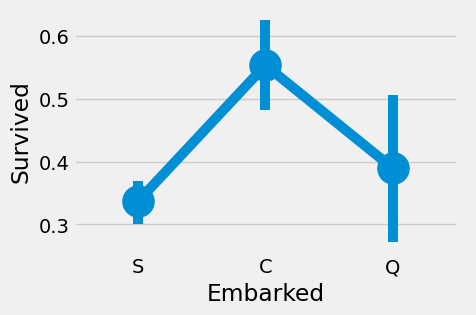

In [27]:
sns.catplot(x='Embarked',y='Survived',data=data, kind='point')
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

승선 항구별 생존 확률을 보면, C 항구에서 탑승한 경우 생존률이 약 0.55로 가장 높고, S 항구에서 탑승한 경우가 가장 낮음.


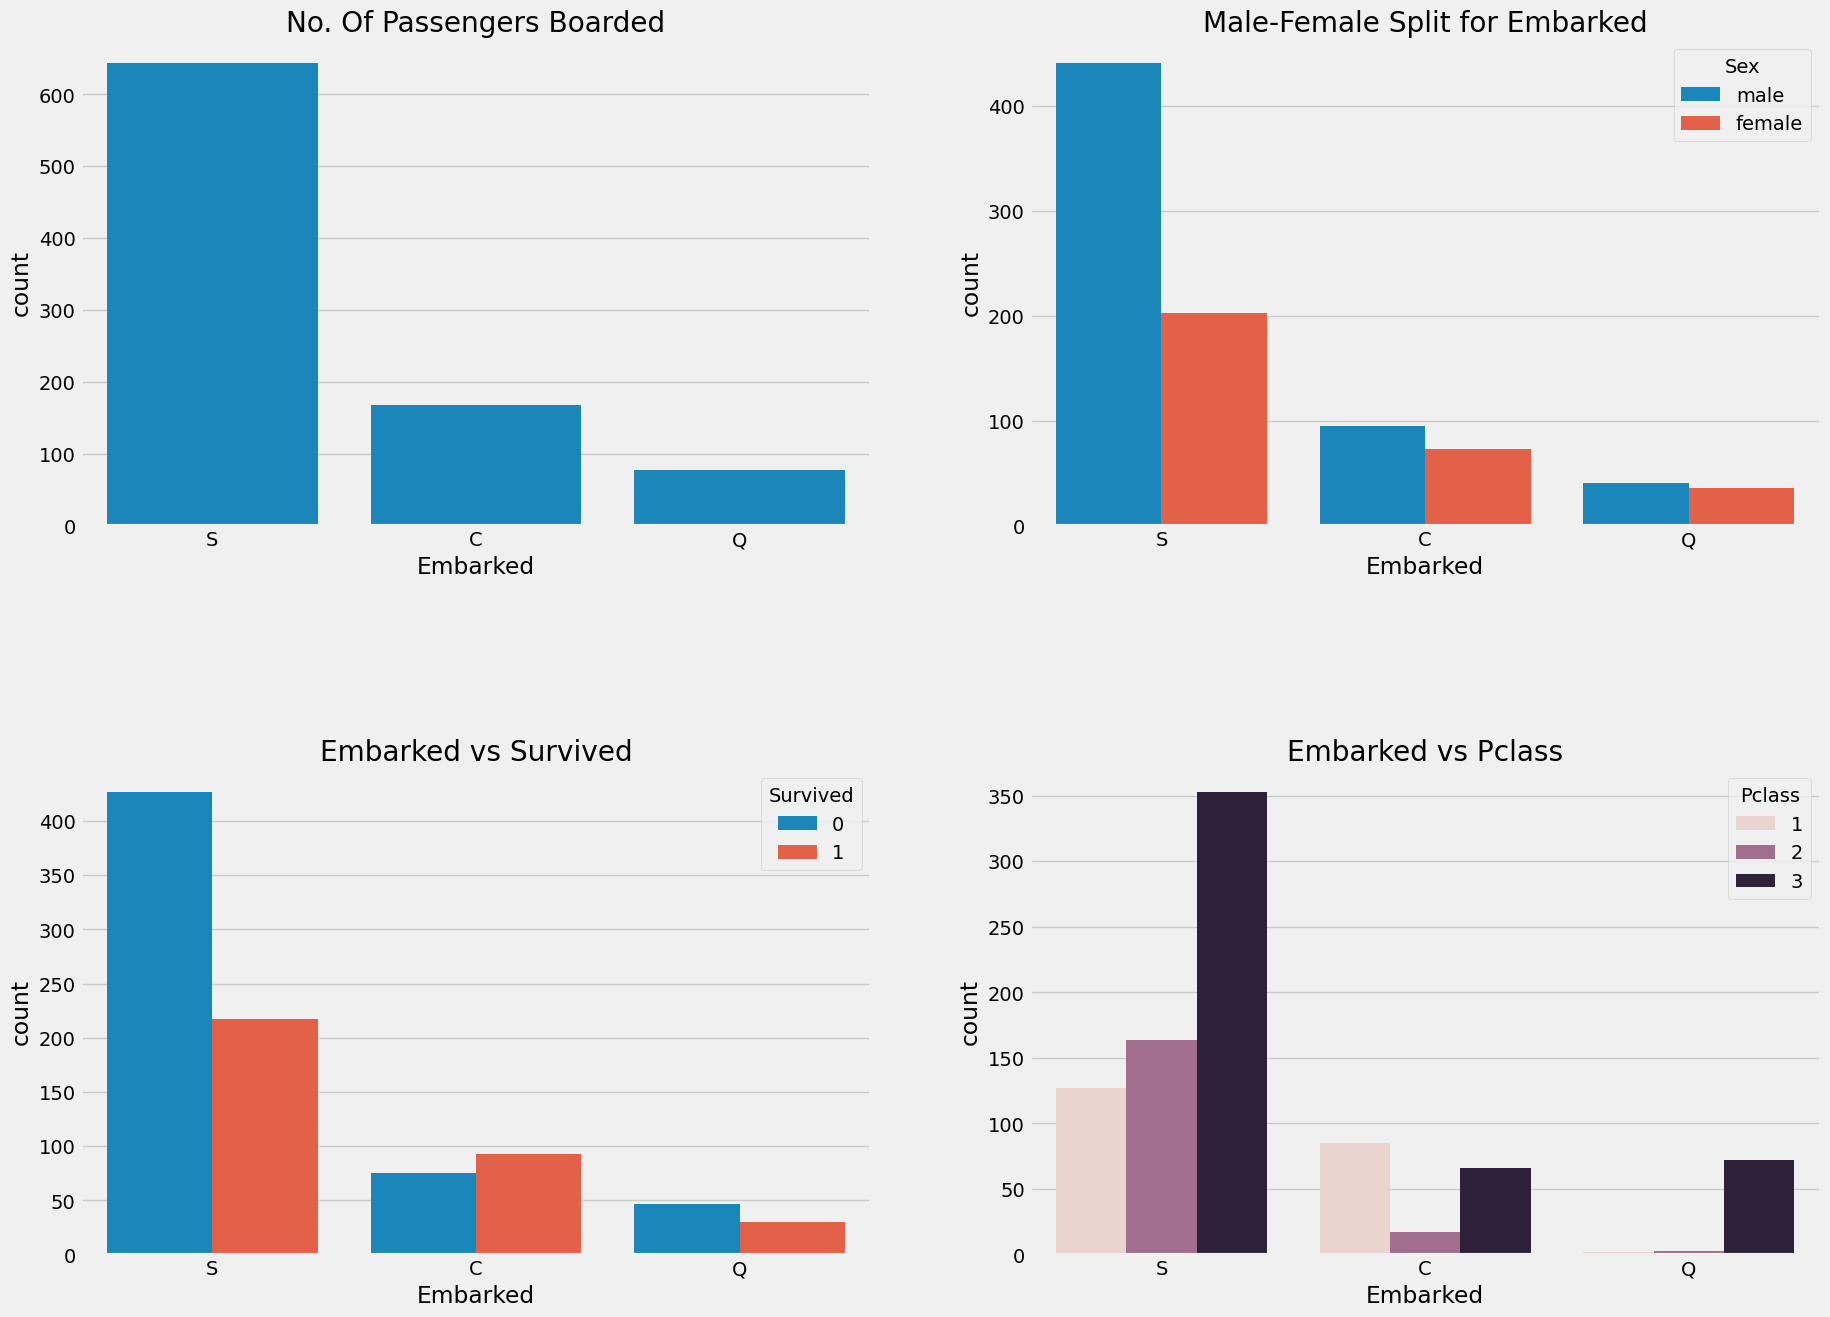

In [29]:
f,ax=plt.subplots(2,2,figsize=(20,15))
sns.countplot(x='Embarked',data=data,ax=ax[0,0])
ax[0,0].set_title('No. Of Passengers Boarded')
sns.countplot(x='Embarked',hue='Sex',data=data,ax=ax[0,1])
ax[0,1].set_title('Male-Female Split for Embarked')
sns.countplot(x='Embarked',hue='Survived',data=data,ax=ax[1,0])
ax[1,0].set_title('Embarked vs Survived')
sns.countplot(x='Embarked',hue='Pclass',data=data,ax=ax[1,1])
ax[1,1].set_title('Embarked vs Pclass')
plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show()

관찰 결과 (Observations):
1. 대부분의 승객은 S 항구에서 승선했으며, 그중 대다수는 3등석(Pclass 3).
2. C 항구에서 승선한 승객들은 비교적 운이 좋았던 것으로 보이며, 상당수가 생존. 이는 1등석과 2등석 승객들이 많이 구조된 영향일 수 있음.
3. S 항구는 부유한 승객들도 많이 탑승한 곳으로 보이지만, 전체 생존률은 낮음. 그 이유는 3등석 승객의 약 81%가 생존하지 못했기 때문.
4. Q 항구의 경우, 승객의 약 95%가 3등석(Pclass 3).

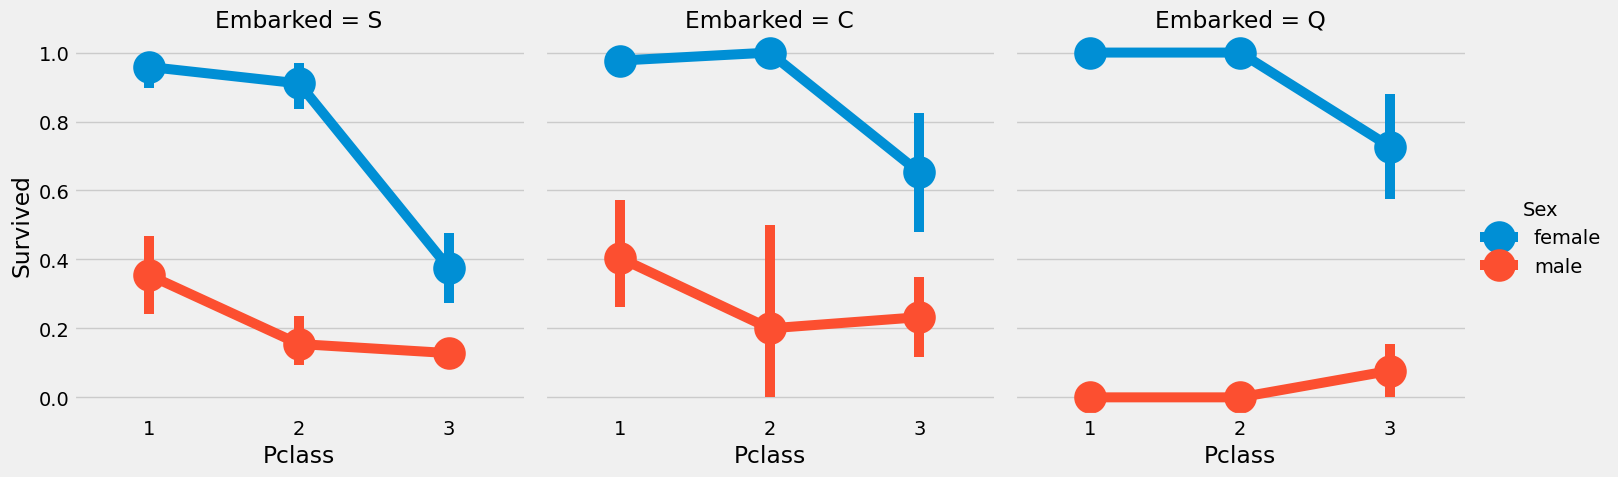

In [32]:
sns.catplot(x='Pclass',y='Survived',hue='Sex',col='Embarked',data=data, kind='point')
plt.show()

관찰 결과 (Observations):
1. 여성의 경우 1등석(Pclass 1)과 2등석(Pclass 2)에서는 객실 등급과 관계없이 생존 확률이 거의 1에 가깝습니다.
2. S 항구는 특히 3등석(Pclass 3) 승객들에게 매우 불리한 것으로 보이며, 남성과 여성 모두 생존률이 매우 낮습니다. (경제적 요인의 영향)
3. Q 항구는 남성 승객에게 가장 불리해 보입니다. 거의 모든 승객이 3등석이었기 때문입니다.

<br>

**Embarked 결측값(NaN) 처리**
앞서 확인했듯이 대부분의 승객이 S 항구에서 승선했기 때문에, Embarked 변수의 결측값은 S로 대체합니다.

In [33]:
data['Embarked'].fillna('S',inplace=True)

In [34]:
data.Embarked.isnull().any()# Finally No NaN values

np.False_

**SibSip → 이산형 변수 (Discrete Feature)**

이 변수는 승객이 혼자인지, 아니면 가족과 함께 탑승했는지를 나타냅니다.

In [35]:
pd.crosstab([data.SibSp],data.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


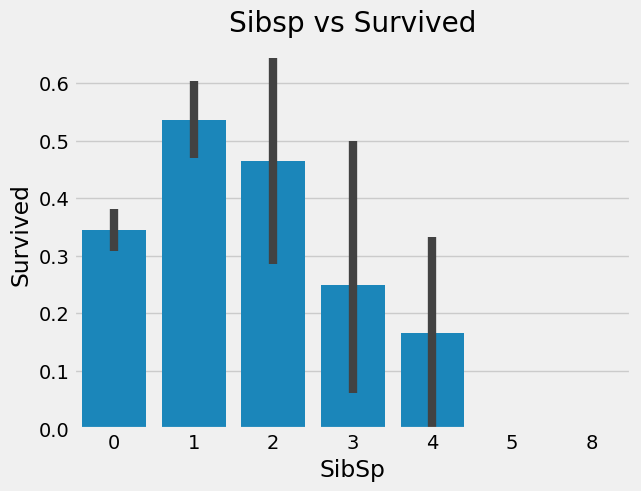

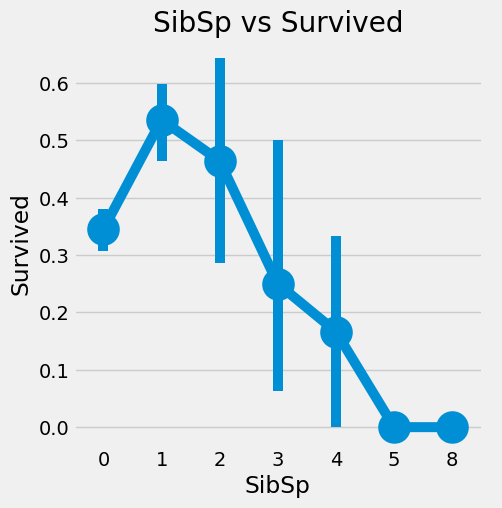

In [40]:
sns.barplot(x='SibSp',y='Survived',data=data)
plt.title('Sibsp vs Survived')
sns.catplot(x='SibSp',y='Survived',data=data, kind='point')
plt.title('SibSp vs Survived')
plt.show()

In [41]:
pd.crosstab(data.SibSp,data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


관찰 결과 (Observations):
막대그래프(barplot)와 factorplot을 보면, 형제자매/배우자(SibSp)가 없이 혼자 탑승한 승객의 생존률은 약 34.5%입니다. 그리고 동반 가족 수(SibSp)가 증가할수록 생존률은 전반적으로 감소하는 경향을 보입니다.

이것은 어느 정도 타당한 해석이 가능합니다. 가족과 함께 있다면, 자신보다 가족을 먼저 구하려는 행동을 할 가능성이 있기 때문입니다.

흥미로운 점은 가족 구성원이 5~8명인 경우 생존률이 0%라는 것입니다. 그 이유는 **객실 등급(Pclass)**과 관련이 있습니다.

교차표(crosstab)를 보면, **SibSp > 3인 승객들은 모두 3등석(Pclass 3)**에 속해 있었습니다. 즉, 3등석에 탑승한 대가족(4명 이상)은 전원 사망한 것으로 나타납니다.

<br>

Parch

In [42]:
pd.crosstab(data.Parch,data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


교차표(crosstab)를 다시 확인해보면, 가족 규모가 클수록 대부분 3등석(Pclass 3)에 속해 있었다는 것을 알 수 있습니다.

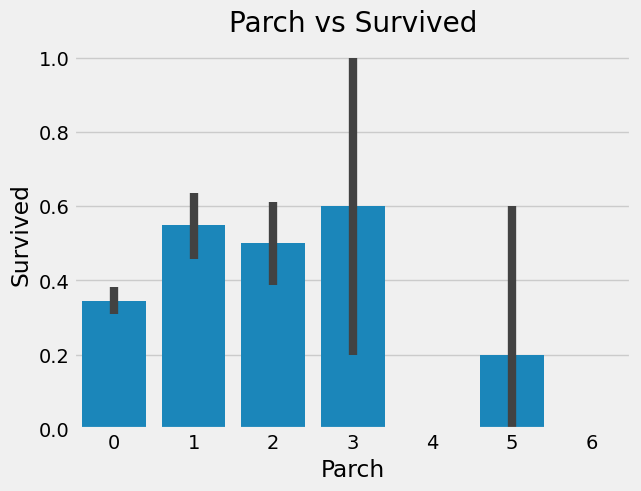

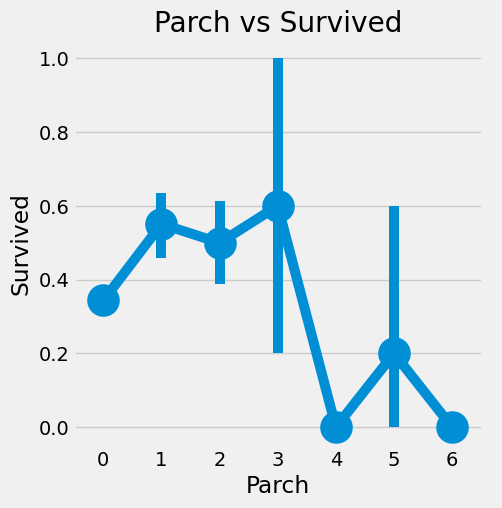

In [43]:
sns.barplot(x='Parch',y='Survived',data=data)
plt.title('Parch vs Survived')
sns.catplot(x='Parch',y='Survived',data=data, kind='point')
plt.title('Parch vs Survived')
plt.show()

관찰 결과 (Observations):
여기서도 결과는 비슷한 패턴을 보입니다. 부모/자녀(Parch)가 함께 탑승한 승객은 혼자인 경우보다 생존 확률이 더 높은 편입니다.

하지만 그 수가 많아질수록 생존률은 다시 감소하는 경향을 보입니다.
특히 Parch 값이 1~3인 경우 생존 확률이 비교적 높고,
혼자인 경우(Parch = 0)는 오히려 생존에 불리한 모습을 보입니다. 또한 Parch가 4 이상으로 많아지면 생존 확률이 다시 낮아집니다.

<br>

**Fare → 연속형 변수 (Continuous Feature)**

In [44]:
print('Highest Fare was:',data['Fare'].max())
print('Lowest Fare was:',data['Fare'].min())
print('Average Fare was:',data['Fare'].mean())

Highest Fare was: 512.3292
Lowest Fare was: 0.0
Average Fare was: 32.204207968574636


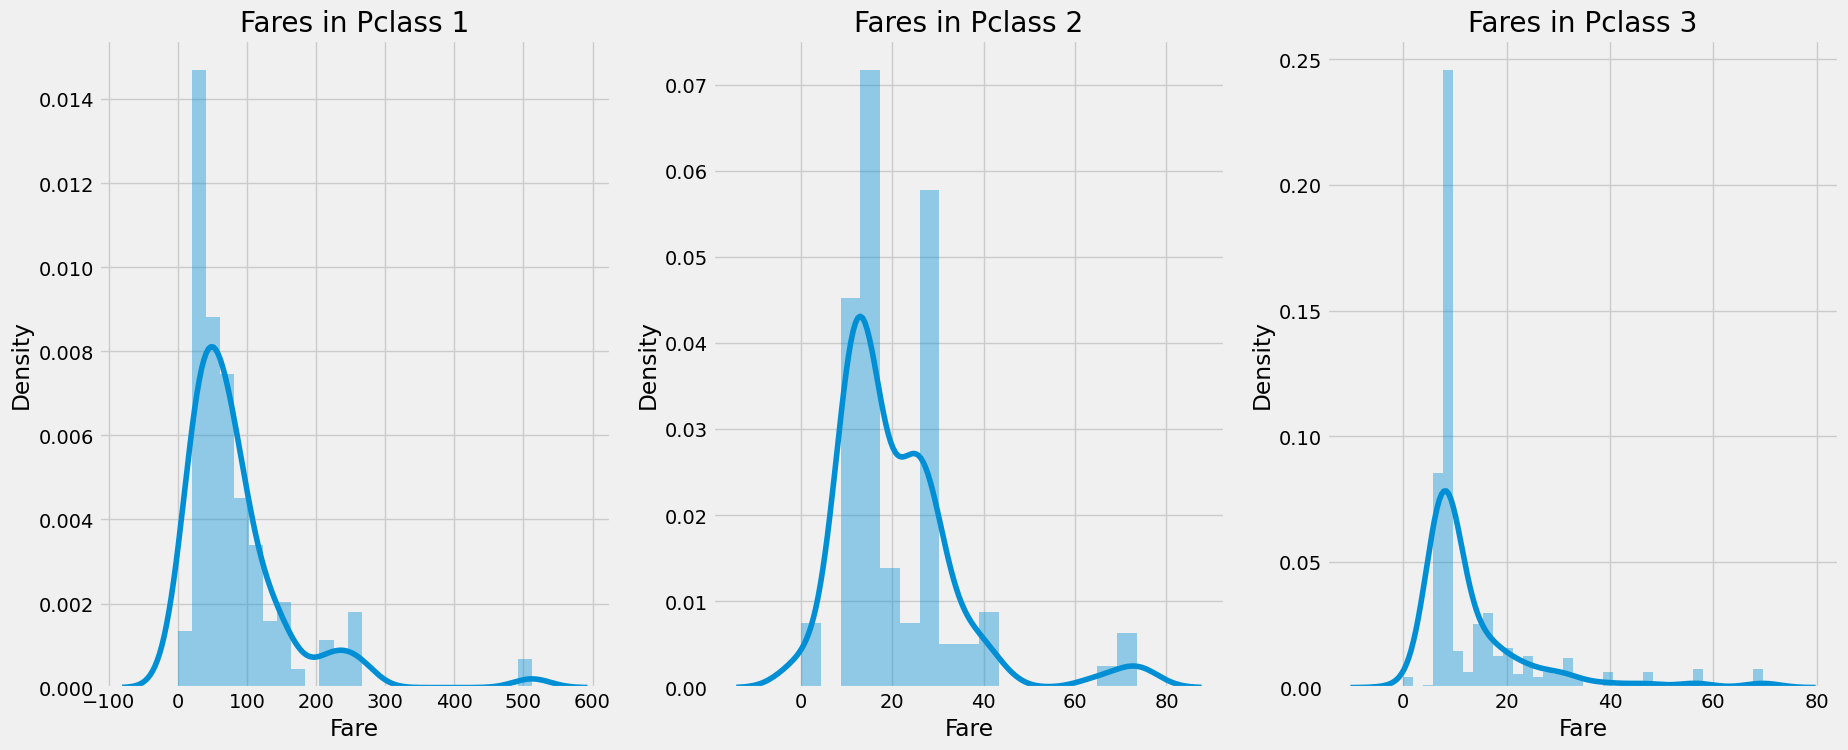

In [45]:
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.distplot(data[data['Pclass']==1].Fare,ax=ax[0])
ax[0].set_title('Fares in Pclass 1')
sns.distplot(data[data['Pclass']==2].Fare,ax=ax[1])
ax[1].set_title('Fares in Pclass 2')
sns.distplot(data[data['Pclass']==3].Fare,ax=ax[2])
ax[2].set_title('Fares in Pclass 3')
plt.show()

요금을 보면 1등석(Pclass 1) 승객들의 요금 분포가 매우 넓게 퍼져 있고, 객실 등급이 낮아질수록(2등석, 3등석) 그 분포는 점점 줄어드는 경향이 있습니다. 또한 Fare 역시 연속형 변수이기 때문에, **구간화(binning)**를*통해 이산형 값으로 변환할 수 있습니다.

---

**전체 변수 요약 (Observations in a Nutshell):**

* **Sex (성별)**:*여성의 생존 확률이 남성보다 훨씬 높습니다.

* **Pclass (객실*등급)**: 1등석일수록 생존 확률이 높고, 3등석은 매우 낮습니다. 특히 여성의 경우 1등석에서는 생존 확률이 거의 1에 가깝고, 2등석에서도 높은 편입니다. → **경제적 여유가 생존에 유리하게 작용**

* **Age (나이)**: 5~10세*이하 어린이는 생존 확률이 높으며, 15~35세 구간에서는 사망자가 많습니다.

* **Embarked (승선*항구)**: C 항구의 생존률이 더 좋아 보이며, S 항구에서 1등석 승객이 많이 탑승했음에도 전체 생존률은 낮습니다. Q 항구 승객은 대부분 3등석입니다.

* **Parch + SibSp (가족*동반 여부)**:
  형제/배우자 1~2명 또는 부모 1~3명과 함께 탑승한 경우 생존 확률이 더 높습니다.
  반대로 혼자이거나, 너무 많은 가족과 함께 탑승한 경우 생존 확률이 낮아집니다.

---

**변수 간 상관관계 (Correlation Between the Features)**

이제 각 변수들이 서로 어떤 관계를 가지는지(상관관계)를 분석해보면,
어떤 변수들이 함께 작용해서 생존에 영향을 미치는지 더 명확하게 이해할 수 있습니다.


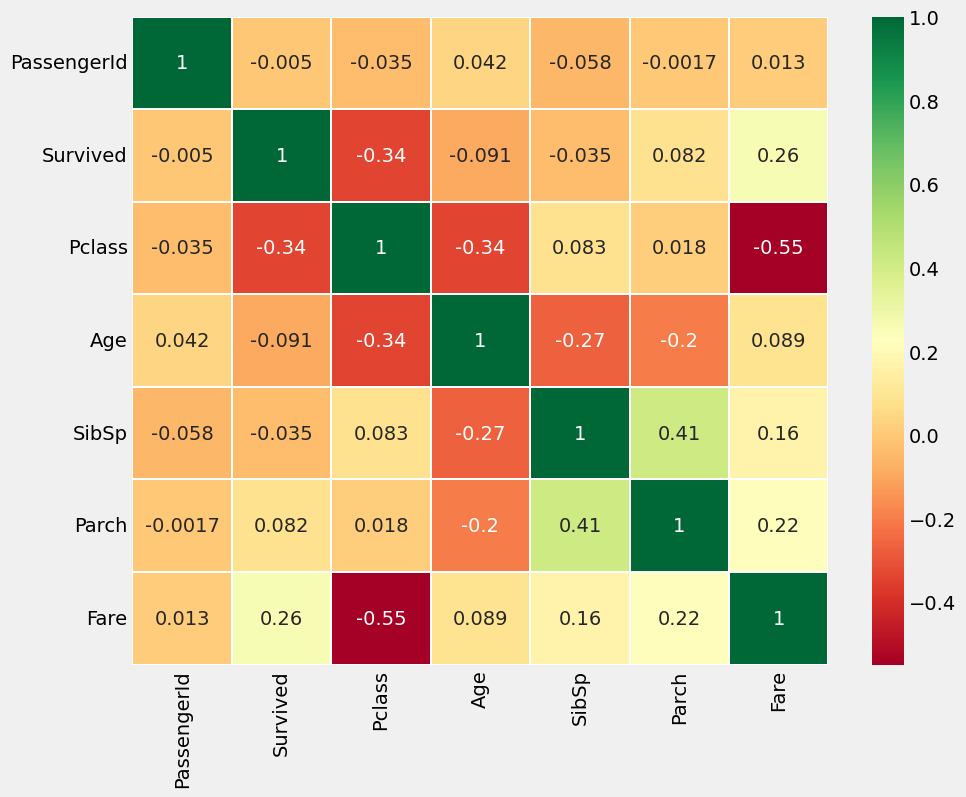

In [48]:
cols = ['PassengerId','Survived','Pclass','Age','SibSp','Parch','Fare']
sns.heatmap(data[cols].corr(),annot=True,cmap='RdYlGn',linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(10,8)
plt.show()

히트맵 해석 (Interpreting the Heatmap)

히트맵을 보면, 변수들 간 상관관계가 전반적으로 크지 않습니다. 가장 높은 상관관계는 SibSp와 Parch 간 0.41 정도입니다. 따라서 현재로서는 모든 변수를 유지해도 괜찮다고 판단할 수 있습니다.

##**파트 2: Feature Engineering & Data Cleaning**

불필요하거나 중복된 변수는 제거해야 합니다
기존 변수로부터 새로운 변수를 만들어낼 수도 있습니다

예를 들어, **Name 변수에서 호칭(Initials)**을 추출한 것이 좋은 예.


또는 **Binning(구간화)**또는 **정규화(Normalization)**

이렇게 하면 연속형 변수였던 Age를 범주형 변수(Age_band)로 변환할 수 있어 모델에 더 잘 활용할 수 있습니다.

In [49]:
data['Age_band']=0
data.loc[data['Age']<=16,'Age_band']=0
data.loc[(data['Age']>16)&(data['Age']<=32),'Age_band']=1
data.loc[(data['Age']>32)&(data['Age']<=48),'Age_band']=2
data.loc[(data['Age']>48)&(data['Age']<=64),'Age_band']=3
data.loc[data['Age']>64,'Age_band']=4
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_band
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2


In [50]:
data['Age_band'].value_counts().to_frame().style.background_gradient(cmap='summer')#checking the number of passenegers in each band

,count
Age_band,
1,382
2,325
0,104
3,69
4,11


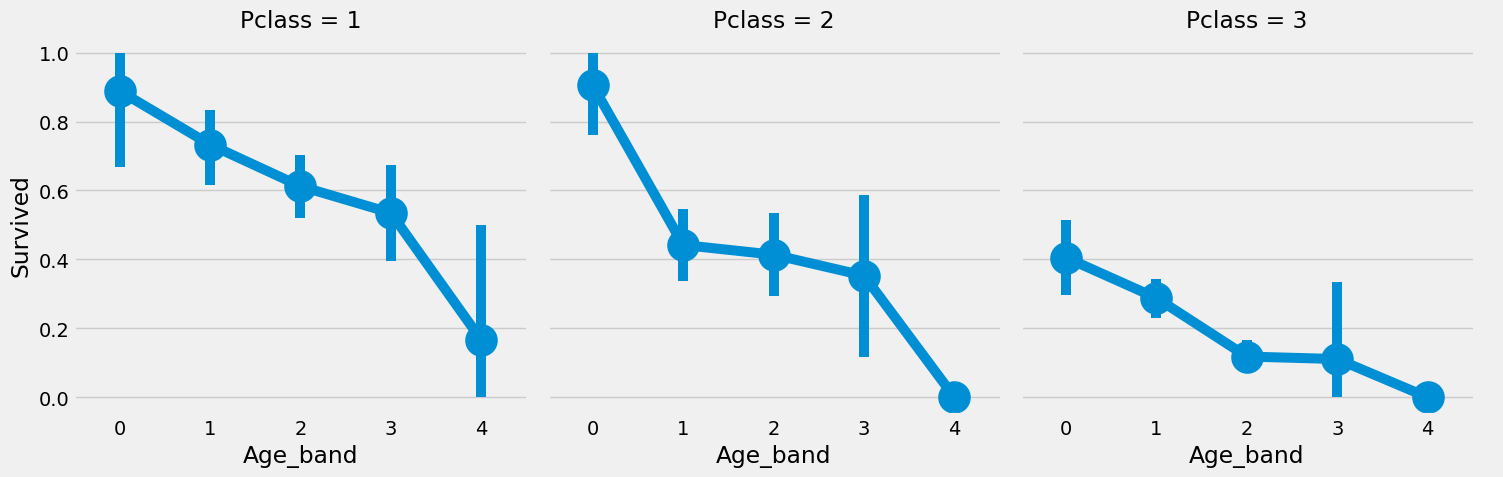

In [53]:
sns.catplot(x='Age_band',y='Survived',data=data,col='Pclass',kind='point')
plt.show()

객실 등급(Pclass)과 관계없이 나이가 증가할수록 생존률은 감소하는 경향을 보입니다.

<br>

**Family_Size와 Alone**

Family_Size = 0 → Alone = 1 (혼자)

Family_Size > 0 → Alone = 0 (가족 있음)

이렇게 두 변수를 새로 만들면,
가족 규모가 생존률에 어떤 영향을 미치는지 더 명확하게 분석할 수 있습니다.

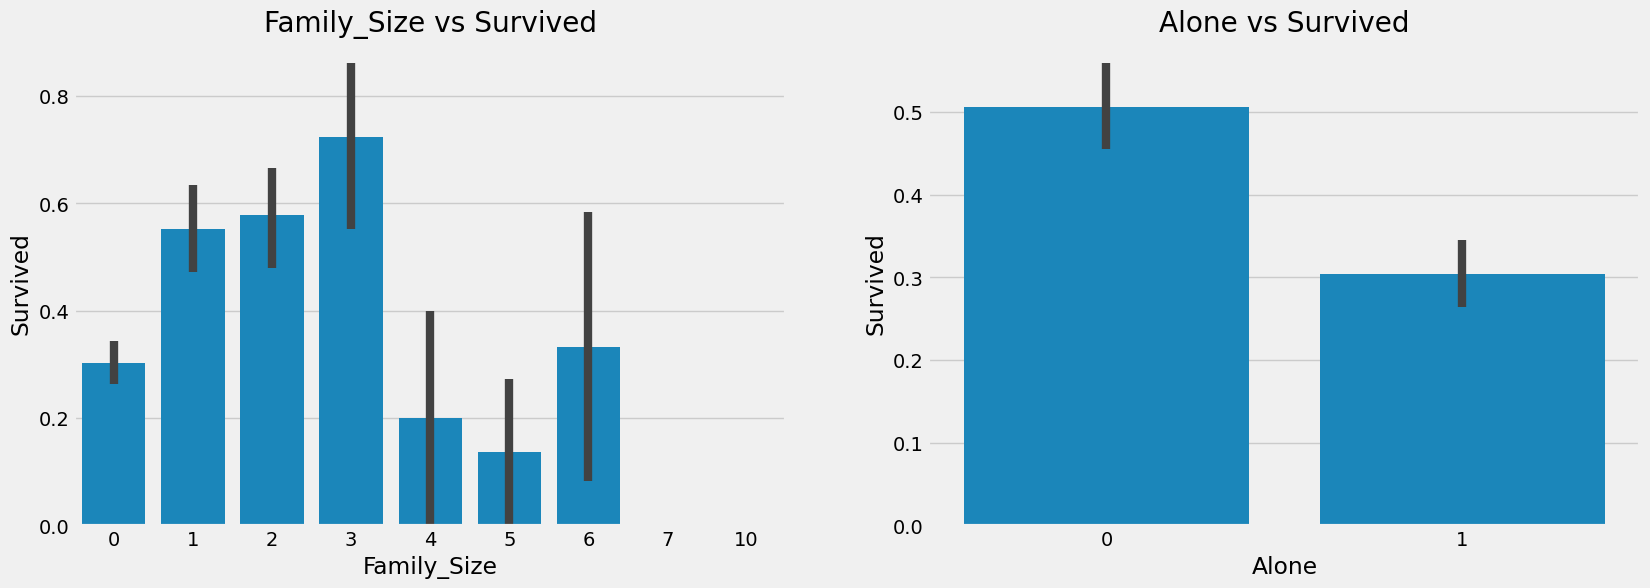

In [57]:
data['Family_Size']=0
data['Family_Size']=data['Parch']+data['SibSp']#family size
data['Alone']=0
data.loc[data.Family_Size==0,'Alone']=1#Alone

f,ax=plt.subplots(1,2,figsize=(18,6))
sns.barplot(x='Family_Size',y='Survived',data=data,ax=ax[0])
ax[0].set_title('Family_Size vs Survived')
sns.barplot(x='Alone',y='Survived',data=data,ax=ax[1])
ax[1].set_title('Alone vs Survived')
plt.close(2)
plt.close(3)
plt.show()

해석 (Observations):

혼자인 경우(Family_Size = 0) 생존 확률이 매우 낮습니다.

또한 가족 규모가 너무 큰 경우(Family_Size > 4)에도 생존 확률이 다시 감소하는 경향이 나타납니다.

즉,
혼자이거나
가족이 너무 많거나
두 경우 모두 생존에 불리하게 작용합니다.

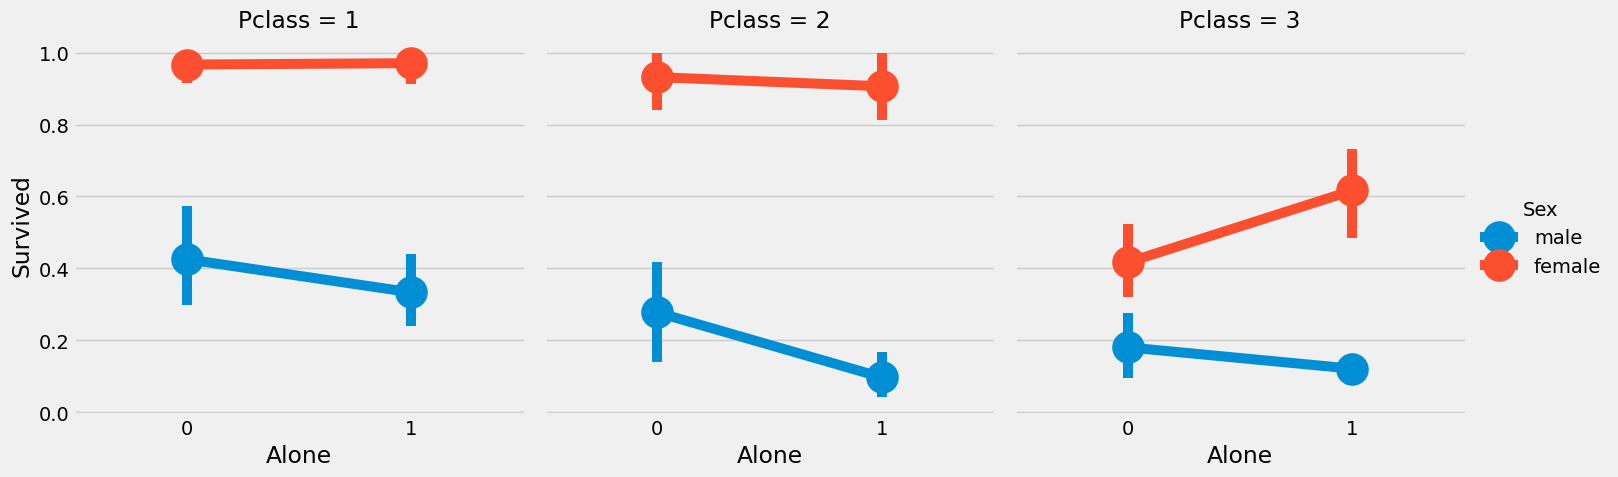

In [59]:
sns.catplot(x='Alone',y='Survived',data=data,hue='Sex',col='Pclass', kind='point')
plt.show()

혼자인 경우는 성별(Sex)이나 객실 등급(Pclass)과 관계없이 전반적으로 생존에 불리하게 작용하는 것이 보입니다. 다만 예외적으로 **3등석(Pclass 3)*여성의 경우**, 혼자인 승객이 가족과 함께 있는 경우보다 생존 확률이 더 높은 경향을 보입니다.

---

**Fare_Range**

Fare(요금) 역시 연속형 변수이기 때문에, 이를 **순서형 변수(ordinal value)**로 변환할 필요가 있습니다. 이를 위해 'pandas.qcut'을 사용할 수 있습니다.

* **qcut의 역할**:
  데이터를 우리가 지정한 구간(bin)의 개수에 맞게 나누어 줍니다.

예를 들어:

* 5개의 구간을 지정하면
  → 데이터를 **비슷한 개수씩 나누어 5개의 구간(범위)**으로 분할합니다.

즉, 단순히 값의 범위를 균등하게 나누는 것이 아니라,
각 구간에 포함되는 데이터의 개수가 비슷하도록 나누는 방식입니다.



In [60]:
data['Fare_Range']=pd.qcut(data['Fare'],4)
data.groupby(['Fare_Range'])['Survived'].mean().to_frame().style.background_gradient(cmap='summer_r')

,Survived
Fare_Range,
"(-0.001, 7.91]",0.197309
"(7.91, 14.454]",0.303571
"(14.454, 31.0]",0.454955
"(31.0, 512.329]",0.581081


요금 구간(Fare_Range)이 증가할수록 생존 확률도 함께 증가하는 경향을 확인할 수 있습니다.

하지만 Fare_Range 값을 현재 형태 그대로 모델에 넣을 수는 없습니다.
따라서 Age_Band에서 했던 것처럼 각 구간을 하나의 단일 값으로 변환

In [61]:
data['Fare_cat']=0
data.loc[data['Fare']<=7.91,'Fare_cat']=0
data.loc[(data['Fare']>7.91)&(data['Fare']<=14.454),'Fare_cat']=1
data.loc[(data['Fare']>14.454)&(data['Fare']<=31),'Fare_cat']=2
data.loc[(data['Fare']>31)&(data['Fare']<=513),'Fare_cat']=3

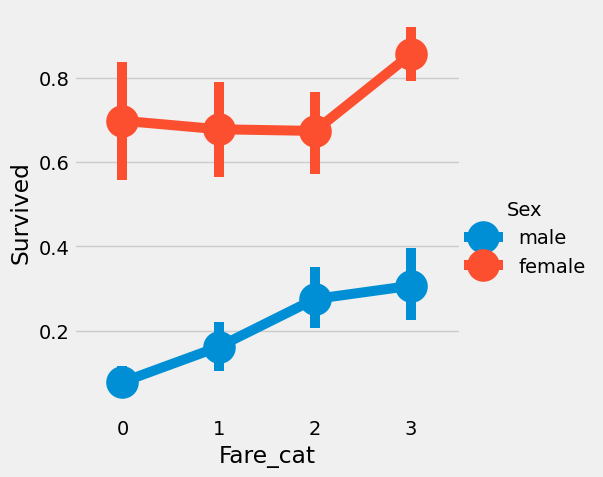

In [62]:
sns.catplot(x='Fare_cat',y='Survived',data=data,hue='Sex', kind='point')
plt.show()

요금 범주(Fare_cat)가 증가할수록 생존 확률도 함께 증가하는 것이 분명하게 보입니다.

<br>

**문자형 값을 숫자형으로 변환하기**

1. 라벨 인코딩 (Label Encoding)
: 각 범주에 숫자를 하나씩 부여


2. 원-핫 인코딩 (One-Hot Encoding)
: 범주별로 새로운 컬럼을 만들어 0/1로 표시


In [63]:
data['Sex'].replace(['male','female'],[0,1],inplace=True)
data['Embarked'].replace(['S','C','Q'],[0,1,2],inplace=True)
data['Initial'].replace(['Mr','Mrs','Miss','Master','Other'],[0,1,2,3,4],inplace=True)

**Dropping UnNeeded Features**

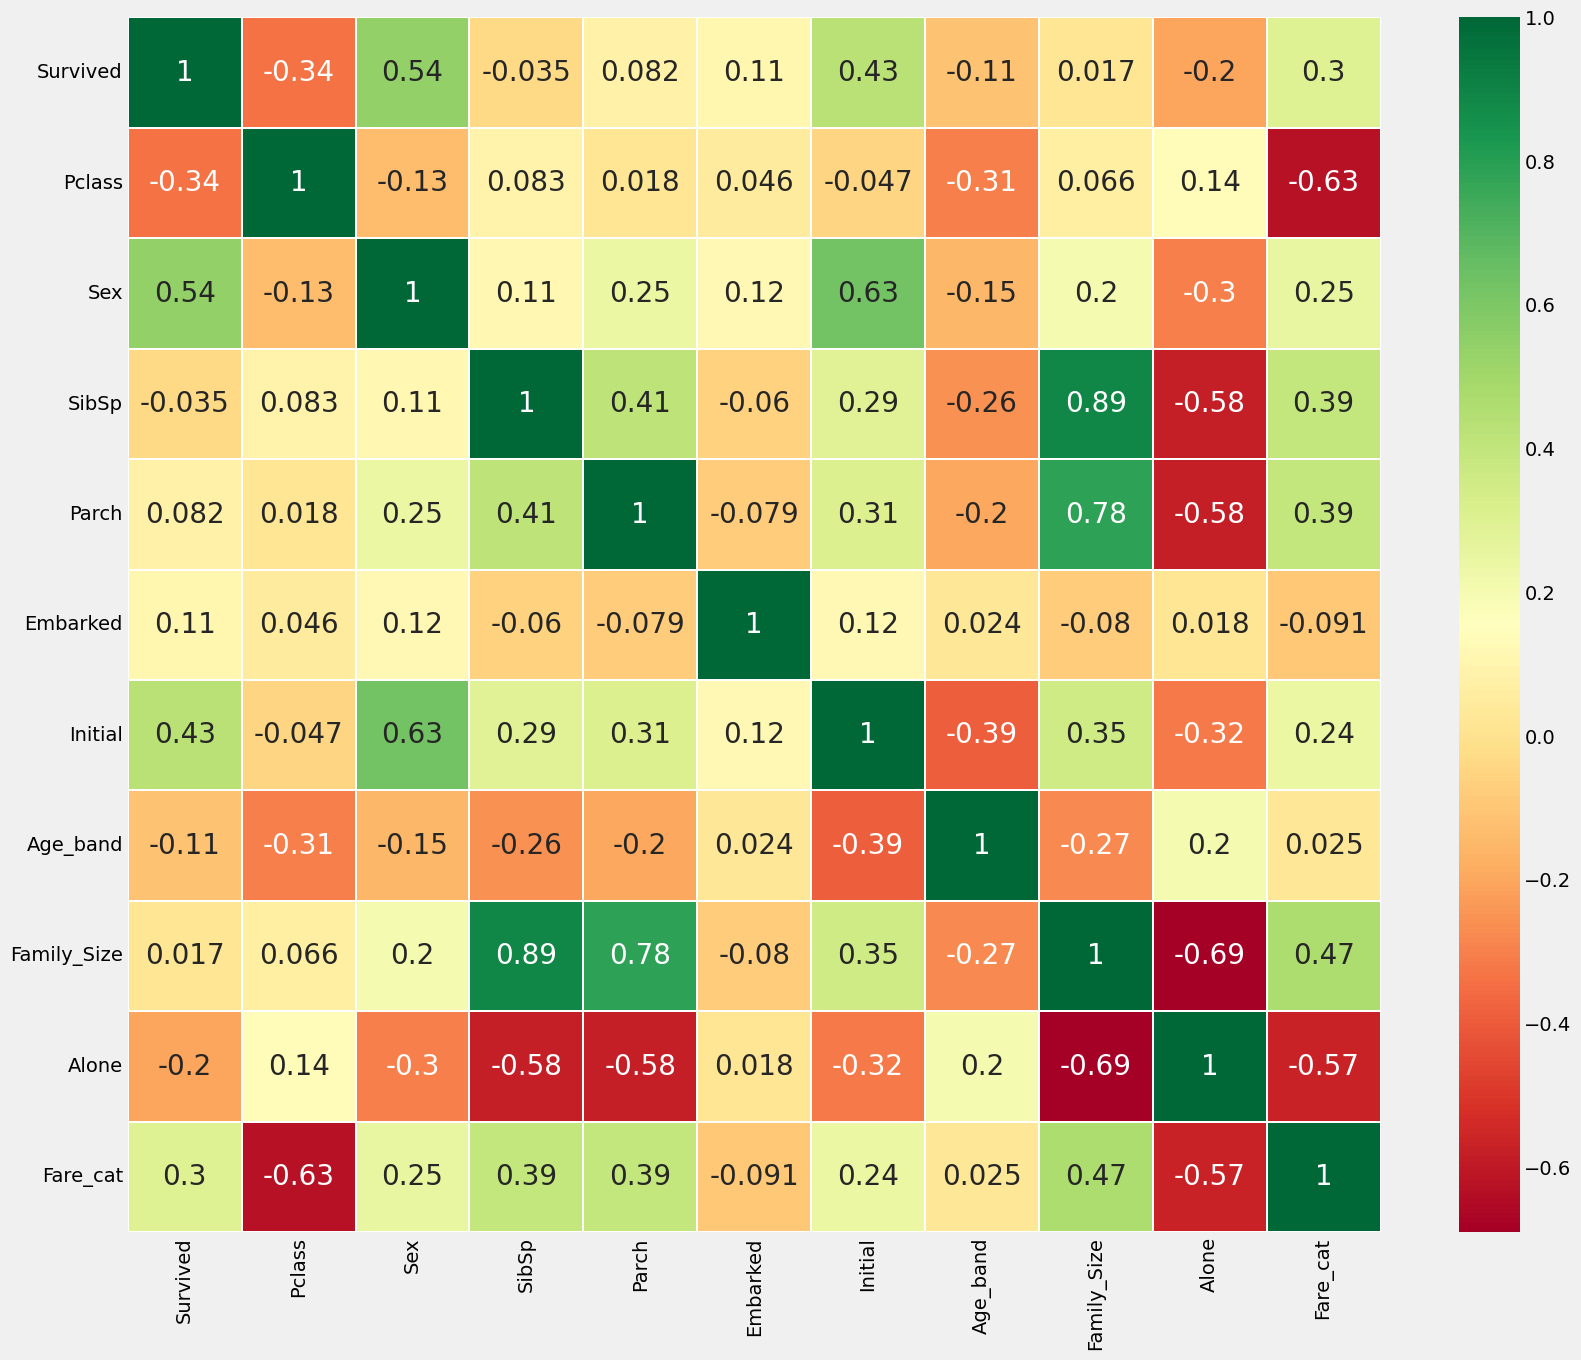

In [64]:
data.drop(['Name','Age','Ticket','Fare','Cabin','Fare_Range','PassengerId'],axis=1,inplace=True)
sns.heatmap(data.corr(),annot=True,cmap='RdYlGn',linewidths=0.2,annot_kws={'size':20})
fig=plt.gcf()
fig.set_size_inches(18,15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

##**파트 3: 예측 모델링**

다양한 분류 알고리즘을 통해 승객의 생존 여부 예측

In [65]:
#importing all the required ML packages
from sklearn.linear_model import LogisticRegression #logistic regression
from sklearn import svm #support vector Machine
from sklearn.ensemble import RandomForestClassifier #Random Forest
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.naive_bayes import GaussianNB #Naive bayes
from sklearn.tree import DecisionTreeClassifier #Decision Tree
from sklearn.model_selection import train_test_split #training and testing data split
from sklearn import metrics #accuracy measure
from sklearn.metrics import confusion_matrix #for confusion matrix

In [66]:
train,test=train_test_split(data,test_size=0.3,random_state=0,stratify=data['Survived'])
train_X=train[train.columns[1:]]
train_Y=train[train.columns[:1]]
test_X=test[test.columns[1:]]
test_Y=test[test.columns[:1]]
X=data[data.columns[1:]]
Y=data['Survived']

**Radial Support Vector Machines(rbf-SVM)**

In [67]:
model=svm.SVC(kernel='rbf',C=1,gamma=0.1)
model.fit(train_X,train_Y)
prediction1=model.predict(test_X)
print('Accuracy for rbf SVM is ',metrics.accuracy_score(prediction1,test_Y))

Accuracy for rbf SVM is  0.835820895522388


**Linear Support Vector Machine(linear-SVM)**

In [68]:
model=svm.SVC(kernel='linear',C=0.1,gamma=0.1)
model.fit(train_X,train_Y)
prediction2=model.predict(test_X)
print('Accuracy for linear SVM is',metrics.accuracy_score(prediction2,test_Y))

Accuracy for linear SVM is 0.8171641791044776


**Logistic Regression**

In [69]:
model = LogisticRegression()
model.fit(train_X,train_Y)
prediction3=model.predict(test_X)
print('The accuracy of the Logistic Regression is',metrics.accuracy_score(prediction3,test_Y))

The accuracy of the Logistic Regression is 0.8134328358208955


**Decision Tree**

In [70]:
model=DecisionTreeClassifier()
model.fit(train_X,train_Y)
prediction4=model.predict(test_X)
print('The accuracy of the Decision Tree is',metrics.accuracy_score(prediction4,test_Y))

The accuracy of the Decision Tree is 0.8097014925373134


**K-Nearest Neighbours(KNN)**

In [71]:
model=KNeighborsClassifier()
model.fit(train_X,train_Y)
prediction5=model.predict(test_X)
print('The accuracy of the KNN is',metrics.accuracy_score(prediction5,test_Y))

The accuracy of the KNN is 0.8134328358208955


KNN 모델의 정확도는 n_neighbors 값에 따라 달라집니다. 기본값은 5이지만, 이 값을 어떻게 설정하느냐에 따라 모델 성능이 크게 변할 수 있습니다.

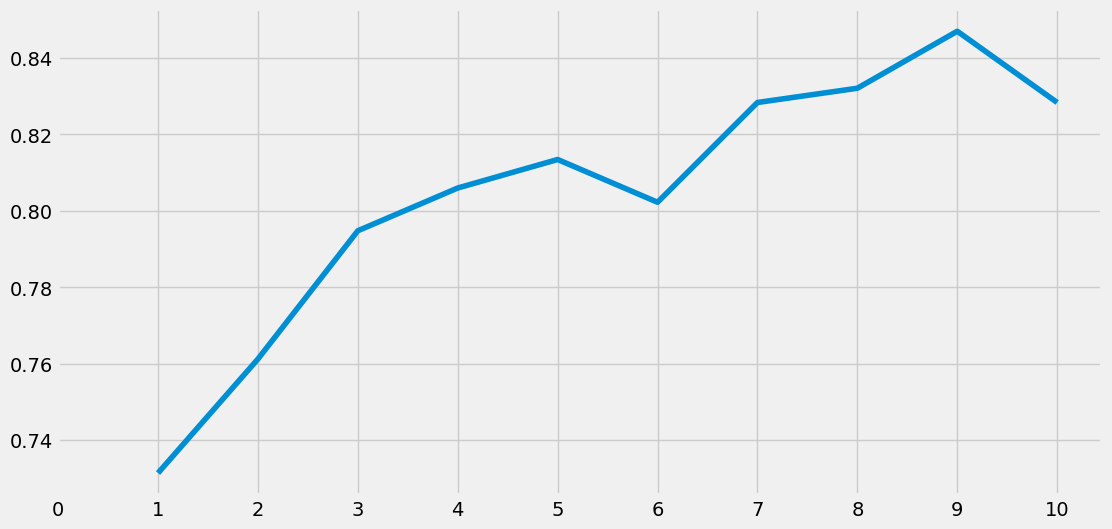

Accuracies for different values of n are: [0.73134328 0.76119403 0.79477612 0.80597015 0.81343284 0.80223881
 0.82835821 0.83208955 0.84701493 0.82835821] with the max value as  0.8470149253731343


In [72]:
a_index=list(range(1,11))
a=pd.Series()
x=[0,1,2,3,4,5,6,7,8,9,10]
for i in list(range(1,11)):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(train_X,train_Y)
    prediction=model.predict(test_X)
    a=pd.concat([a, pd.Series([metrics.accuracy_score(prediction, test_Y)])], ignore_index=True)
plt.plot(a_index, a)
plt.xticks(x)
fig=plt.gcf()
fig.set_size_inches(12,6)
plt.show()
print('Accuracies for different values of n are:',a.values,'with the max value as ',a.values.max())

**Gaussian Naive Bayes**

In [73]:
model=GaussianNB()
model.fit(train_X,train_Y)
prediction6=model.predict(test_X)
print('The accuracy of the NaiveBayes is',metrics.accuracy_score(prediction6,test_Y))

The accuracy of the NaiveBayes is 0.8134328358208955


**Random Forests**

In [74]:
model=RandomForestClassifier(n_estimators=100)
model.fit(train_X,train_Y)
prediction7=model.predict(test_X)
print('The accuracy of the Random Forests is',metrics.accuracy_score(prediction7,test_Y))

The accuracy of the Random Forests is 0.8246268656716418


모델의 정확도(accuracy)만으로 분류기의 성능을 판단할 수는 없습니다.
학습 데이터와 테스트 데이터가 어떻게 나뉘느냐에 따라 결과가 달라질 수 있기 때문입니다.

데이터 분할이 바뀌면 정확도도 증가하거나 감소할 수 있습니다. 이를 모델의 분산(model variance)이라고 합니다.

이 문제를 해결하고 일반화된 모델(generalized model)을 얻기 위해 사용하는 방법이 바로 **교차 검증(Cross Validation)**입니다.

---

**교차 검증 (Cross Validation)**

데이터는 종종 불균형(imbalanced)할 수 있습니다. 즉, 한 클래스의 데이터는 많고 다른 클래스는 적을 수 있습니다.
따라서 데이터셋의 모든 데이터를 골고루 사용해 학습과 평가를 하는 것이 중요합니다.

In [75]:
from sklearn.model_selection import KFold #for K-fold cross validation
from sklearn.model_selection import cross_val_score #score evaluation
from sklearn.model_selection import cross_val_predict #prediction
kfold = KFold(n_splits=10, shuffle=True, random_state=22) # k=10, split the data into 10 equal parts
xyz=[]
accuracy=[]
std=[]
classifiers=['Linear Svm','Radial Svm','Logistic Regression','KNN','Decision Tree','Naive Bayes','Random Forest']
models=[svm.SVC(kernel='linear'),svm.SVC(kernel='rbf'),LogisticRegression(),KNeighborsClassifier(n_neighbors=9),DecisionTreeClassifier(),GaussianNB(),RandomForestClassifier(n_estimators=100)]
for i in models:
    model = i
    cv_result = cross_val_score(model,X,Y, cv = kfold,scoring = "accuracy")
    cv_result=cv_result
    xyz.append(cv_result.mean())
    std.append(cv_result.std())
    accuracy.append(cv_result)
new_models_dataframe2=pd.DataFrame({'CV Mean':xyz,'Std':std},index=classifiers)
new_models_dataframe2

,CV Mean,Std
Linear Svm,0.784607,0.057841
Radial Svm,0.828377,0.057096
Logistic Regression,0.799176,0.040154
KNN,0.808140,0.035630
Decision Tree,0.802497,0.046242
Naive Bayes,0.795843,0.054861
Random Forest,0.809238,0.050087


<Axes: >

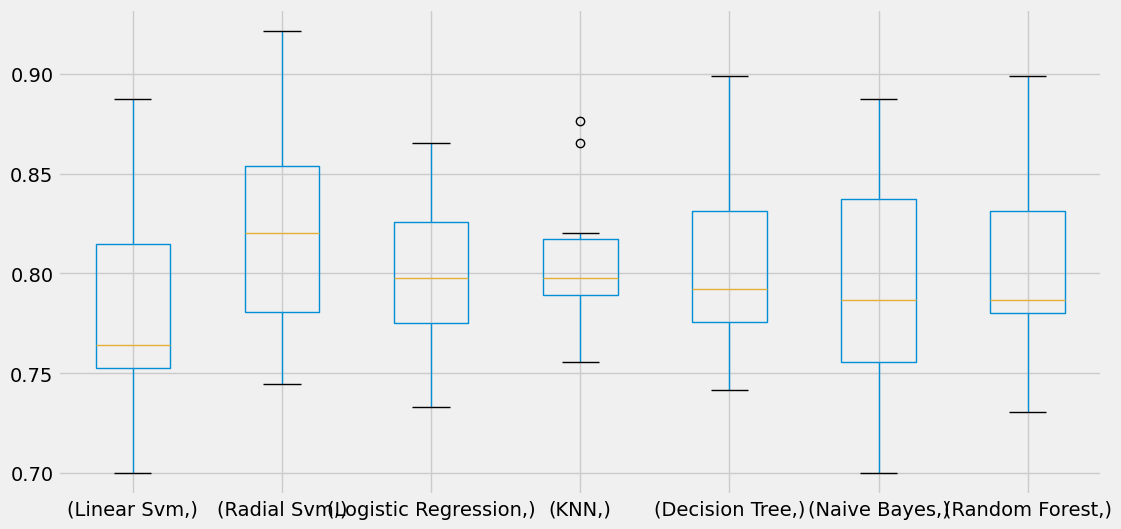

In [76]:
plt.subplots(figsize=(12,6))
box=pd.DataFrame(accuracy,index=[classifiers])
box.T.boxplot()

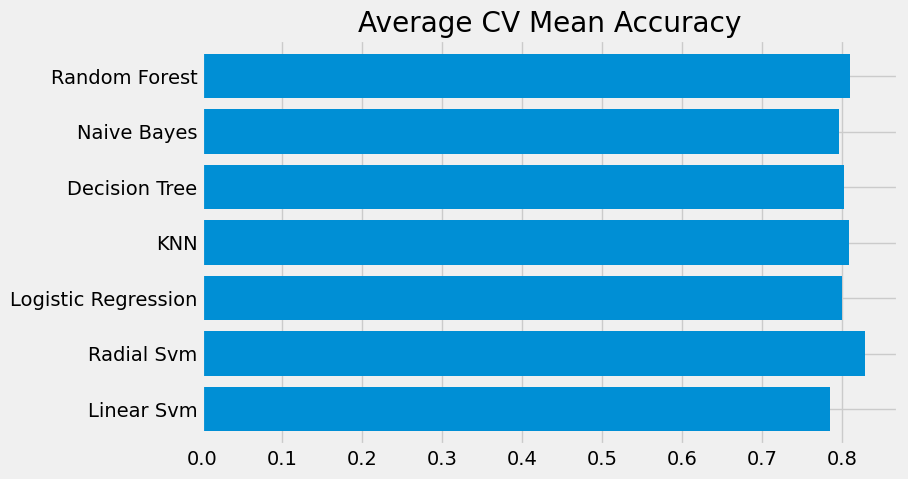

In [77]:
new_models_dataframe2['CV Mean'].plot.barh(width=0.8)
plt.title('Average CV Mean Accuracy')
fig=plt.gcf()
fig.set_size_inches(8,5)
plt.show()

분류 정확도(accuracy)는 데이터 불균형이 있는 경우 오해를 불러일으킬 수 있습니다.
이때 모델이 어디에서 틀렸는지, 어떤 클래스를 잘못 예측했는지를 확인하기 위해 **혼동 행렬(Confusion Matrix)**을 사용할 수 있습니다.

---

**Confusion Matrix**
혼동 행렬은 분류 모델이 수행한 정확한 예측과 잘못된 예측의 개수를 보여주는 표입니다.

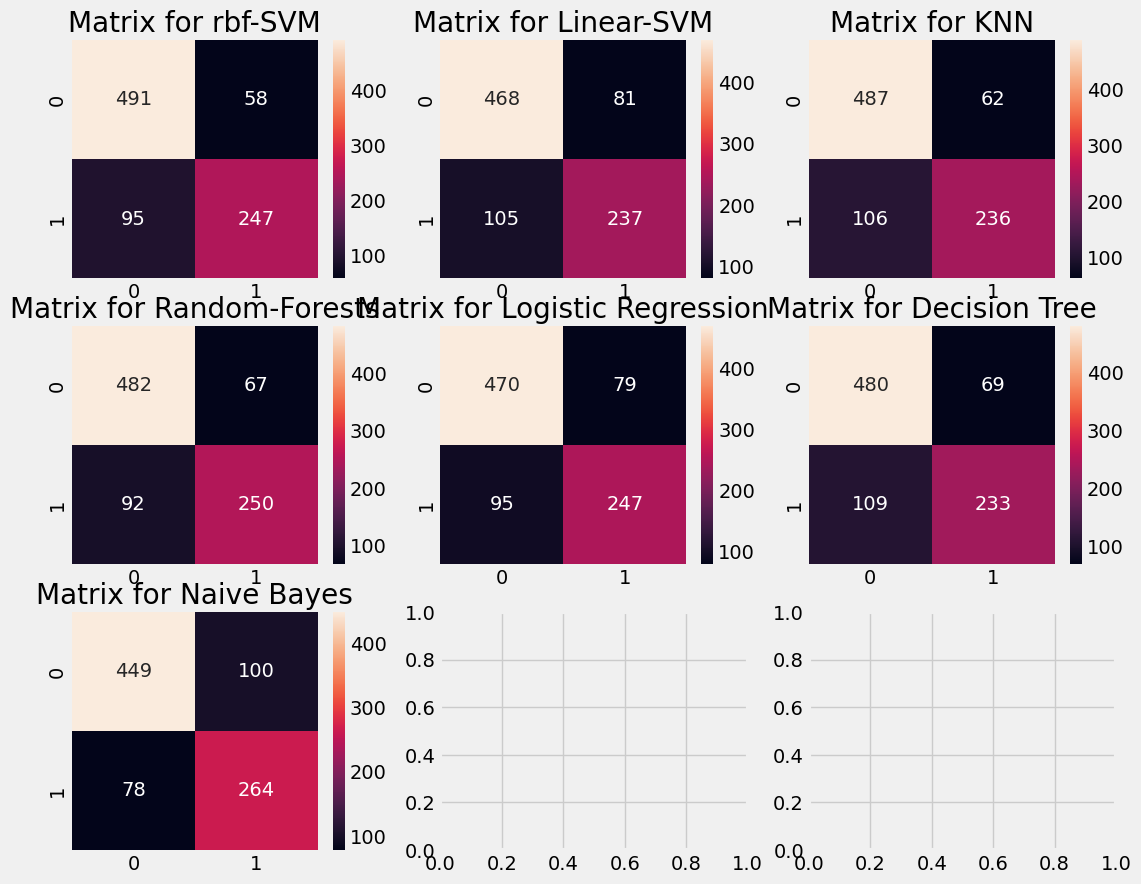

In [78]:
f,ax=plt.subplots(3,3,figsize=(12,10))
y_pred = cross_val_predict(svm.SVC(kernel='rbf'),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,0],annot=True,fmt='2.0f')
ax[0,0].set_title('Matrix for rbf-SVM')
y_pred = cross_val_predict(svm.SVC(kernel='linear'),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,1],annot=True,fmt='2.0f')
ax[0,1].set_title('Matrix for Linear-SVM')
y_pred = cross_val_predict(KNeighborsClassifier(n_neighbors=9),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,2],annot=True,fmt='2.0f')
ax[0,2].set_title('Matrix for KNN')
y_pred = cross_val_predict(RandomForestClassifier(n_estimators=100),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,0],annot=True,fmt='2.0f')
ax[1,0].set_title('Matrix for Random-Forests')
y_pred = cross_val_predict(LogisticRegression(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,1],annot=True,fmt='2.0f')
ax[1,1].set_title('Matrix for Logistic Regression')
y_pred = cross_val_predict(DecisionTreeClassifier(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,2],annot=True,fmt='2.0f')
ax[1,2].set_title('Matrix for Decision Tree')
y_pred = cross_val_predict(GaussianNB(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[2,0],annot=True,fmt='2.0f')
ax[2,0].set_title('Matrix for Naive Bayes')
plt.subplots_adjust(hspace=0.2,wspace=0.2)
plt.show()

혼동 행렬에서 왼쪽 대각선은 각 클래스에 대해 올바르게 예측한 개수를 나타내고,
오른쪽 대각선은 잘못 예측한 개수를 나타냅니다.

모든 혼동 행렬을 종합해보면:
rbf-SVM은 사망자를 정확히 예측하는 데 더 강점이 있고
Naive Bayes는 생존자를 정확히 예측하는 데 더 강점이 있습니다.

---

**하이퍼파라미터 튜닝**

머신러닝 모델은 일종의 블랙박스처럼 동작하며, 기본적으로 설정된 여러 파라미터 값들이 존재합니다. 이 값들을 조정하면 더 좋은 성능을 얻을 수 있습니다.

<br>

**SvM**

In [79]:
from sklearn.model_selection import GridSearchCV
C=[0.05,0.1,0.2,0.3,0.25,0.4,0.5,0.6,0.7,0.8,0.9,1]
gamma=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
kernel=['rbf','linear']
hyper={'kernel':kernel,'C':C,'gamma':gamma}
gd=GridSearchCV(estimator=svm.SVC(),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
0.8282593685267716
SVC(C=0.4, gamma=0.3)


**Random Forests**

In [80]:
n_estimators=range(100,1000,100)
hyper={'n_estimators':n_estimators}
gd=GridSearchCV(estimator=RandomForestClassifier(random_state=0),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
0.819327098110602
RandomForestClassifier(n_estimators=300, random_state=0)


RBF 커널을 사용한 SVM 모델의 최고 성능은
C = 0.05, gamma = 0.1일 때 약 82.82%입니다.

Random Forest의 경우,
n_estimators = 900일 때 약 81.8%의 정확도를 보입니다.

**앙상블**

앙상블은 모델의 정확도나 성능을 향상시키는 좋은 방법입니다.
간단히 말해, 여러 개의 단순한 모델을 결합하여 하나의 강력한 모델을 만드는 것

---

**Voting Classifier (보팅 분류기)**
여러 개의 서로 다른 머신러닝 모델의 예측 결과를 결합하는 가장 간단한 방법

In [81]:
from sklearn.ensemble import VotingClassifier
ensemble_lin_rbf=VotingClassifier(estimators=[('KNN',KNeighborsClassifier(n_neighbors=10)),
                                              ('RBF',svm.SVC(probability=True,kernel='rbf',C=0.5,gamma=0.1)),
                                              ('RFor',RandomForestClassifier(n_estimators=500,random_state=0)),
                                              ('LR',LogisticRegression(C=0.05)),
                                              ('DT',DecisionTreeClassifier(random_state=0)),
                                              ('NB',GaussianNB()),
                                              ('svm',svm.SVC(kernel='linear',probability=True))
                                             ],
                       voting='soft').fit(train_X,train_Y)
print('The accuracy for ensembled model is:',ensemble_lin_rbf.score(test_X,test_Y))
cross=cross_val_score(ensemble_lin_rbf,X,Y, cv = 10,scoring = "accuracy")
print('The cross validated score is',cross.mean())

The accuracy for ensembled model is: 0.8171641791044776
The cross validated score is 0.8249188514357053


**배깅**

배깅은 일반적인 앙상블 기법입니다.

데이터셋을 여러 개의 작은 부분으로 나눈 뒤, 같은 종류의 분류기를 각각 적용하고,
모든 예측 결과를 평균내어 최종 결과를 도출합니다.

---

**배깅 KNN**

배깅은 특히 분산이 큰(high variance) 모델에서 효과가 좋습니다.

대표적인 예로는:

의사결정나무(Decision Tree)

랜덤 포레스트(Random Forest)

또한 KNN에서도 n_neighbors 값을 작게 설정한 경우 (즉, 변동성이 큰 경우)
배깅을 적용하면 성능 개선을 기대할 수 있습니다.

In [83]:
from sklearn.ensemble import BaggingClassifier
model=BaggingClassifier(estimator=KNeighborsClassifier(n_neighbors=3),random_state=0,n_estimators=700)
model.fit(train_X,train_Y)
prediction=model.predict(test_X)
print('The accuracy for bagged KNN is:',metrics.accuracy_score(prediction,test_Y))
result=cross_val_score(model,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for bagged KNN is:',result.mean())

The accuracy for bagged KNN is: 0.832089552238806
The cross validated score for bagged KNN is: 0.8104244694132333


**Bagged DecisionTree**

In [84]:
model=BaggingClassifier(estimator=DecisionTreeClassifier(),random_state=0,n_estimators=100)
model.fit(train_X,train_Y)
prediction=model.predict(test_X)
print('The accuracy for bagged Decision Tree is:',metrics.accuracy_score(prediction,test_Y))
result=cross_val_score(model,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for bagged Decision Tree is:',result.mean())

The accuracy for bagged Decision Tree is: 0.8208955223880597
The cross validated score for bagged Decision Tree is: 0.8171410736579275


**Boosting**

부스팅은 분류기를 순차적으로 학습시키는 앙상블 기법입니다.

약한 모델(weak model)을 단계적으로 개선해 나가는 방식

---

**AdaBoost (Adaptive Boosting)**

AdaBoost에서는 기본적으로 약한 학습기(weak learner)로
의사결정나무를 사용합니다.
하지만 기본 설정(base_estimator)은 변경할 수 있어서,
원하는 다른 알고리즘으로도 대체할 수 있습니다.

In [85]:
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier(n_estimators=200,random_state=0,learning_rate=0.1)
result=cross_val_score(ada,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for AdaBoost is:',result.mean())

The cross validated score for AdaBoost is: 0.8136828963795256


**Stochastic Gradient Boosting**

In [86]:
from sklearn.ensemble import GradientBoostingClassifier
grad=GradientBoostingClassifier(n_estimators=500,random_state=0,learning_rate=0.1)
result=cross_val_score(grad,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for Gradient Boosting is:',result.mean())

The cross validated score for Gradient Boosting is: 0.8115230961298376


**XGBoost**

In [87]:
import xgboost as xg
xgboost=xg.XGBClassifier(n_estimators=900,learning_rate=0.1)
result=cross_val_score(xgboost,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for XGBoost is:',result.mean())

The cross validated score for XGBoost is: 0.8182771535580524


**Hyper-Parameter Tuning for AdaBoost**

In [88]:
n_estimators=list(range(100,1100,100))
learn_rate=[0.05,0.1,0.2,0.3,0.25,0.4,0.5,0.6,0.7,0.8,0.9,1]
hyper={'n_estimators':n_estimators,'learning_rate':learn_rate}
gd=GridSearchCV(estimator=AdaBoostClassifier(),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
0.8293892411022534
AdaBoostClassifier(learning_rate=0.4, n_estimators=800)


**Confusion Matrix for the Best Model**

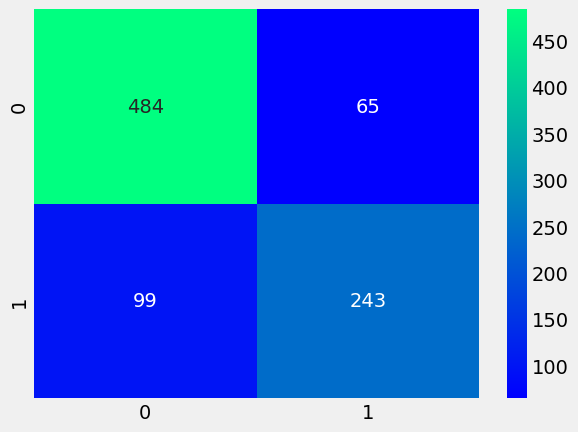

In [89]:
ada=AdaBoostClassifier(n_estimators=200,random_state=0,learning_rate=0.05)
result=cross_val_predict(ada,X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,result),cmap='winter',annot=True,fmt='2.0f')
plt.show()

##**Feature Importance**

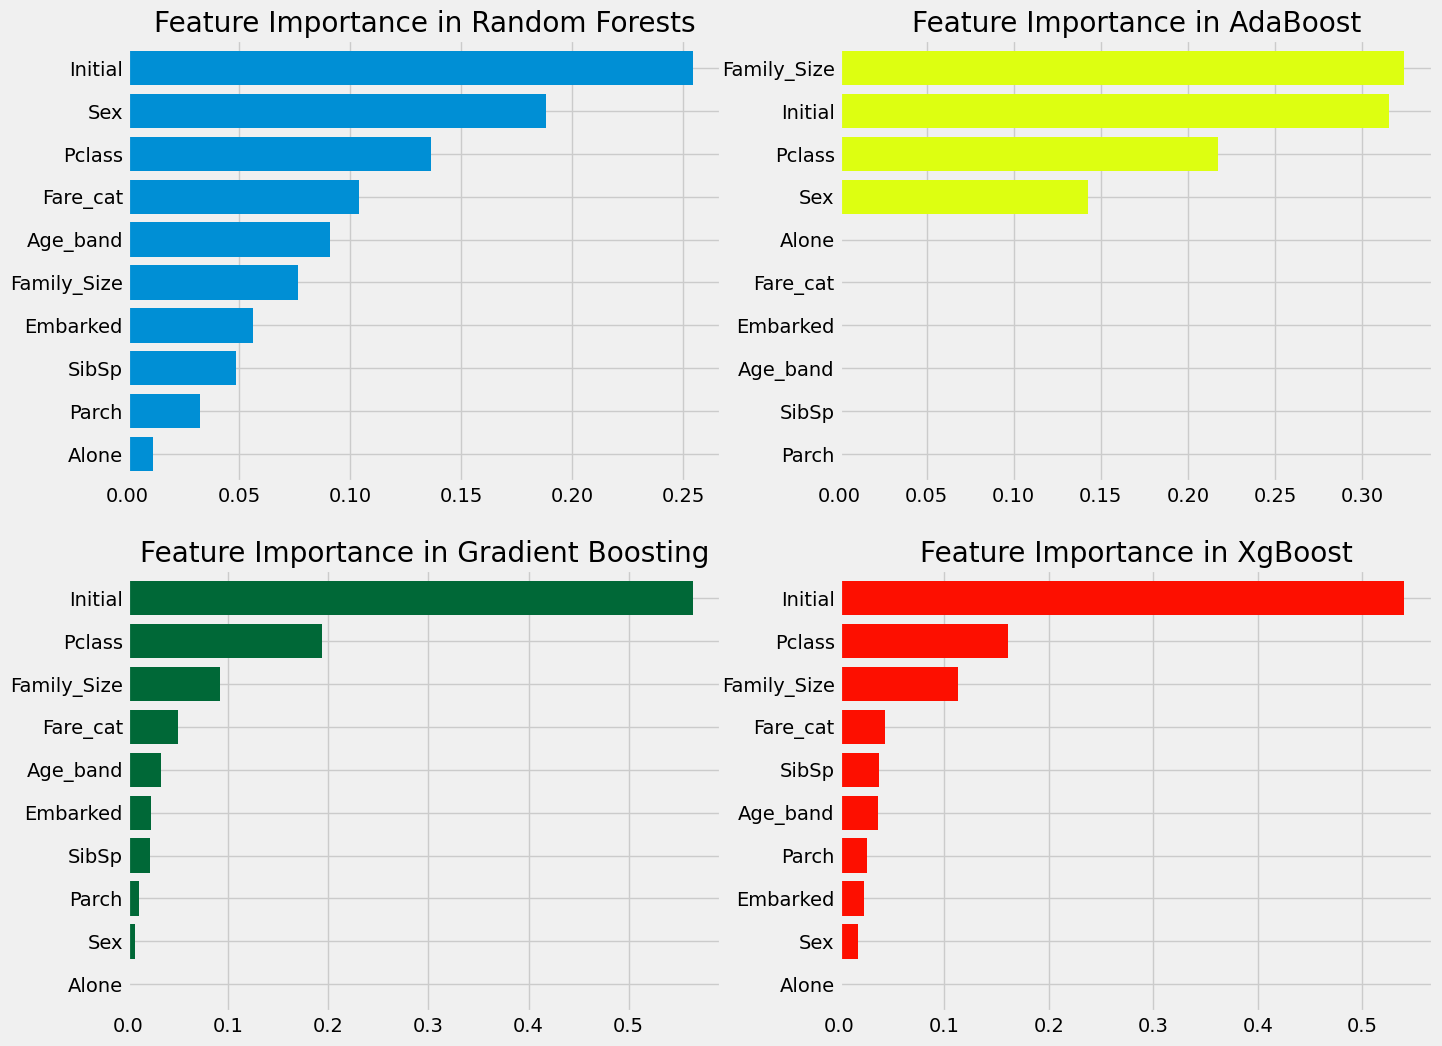

In [90]:
f,ax=plt.subplots(2,2,figsize=(15,12))
model=RandomForestClassifier(n_estimators=500,random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[0,0])
ax[0,0].set_title('Feature Importance in Random Forests')
model=AdaBoostClassifier(n_estimators=200,learning_rate=0.05,random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[0,1],color='#ddff11')
ax[0,1].set_title('Feature Importance in AdaBoost')
model=GradientBoostingClassifier(n_estimators=500,learning_rate=0.1,random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[1,0],cmap='RdYlGn_r')
ax[1,0].set_title('Feature Importance in Gradient Boosting')
model=xg.XGBClassifier(n_estimators=900,learning_rate=0.1)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[1,1],color='#FD0F00')
ax[1,1].set_title('Feature Importance in XgBoost')
plt.show()

관찰 결과 (Observations):

공통적으로 중요한 변수들은
Initial(호칭), Fare_cat(요금*구간), Pclass(객실 등급), Family_Size(가족 규모)입니다.

Sex 변수는 중요도가 낮게 나타나는데, 이는 다소 놀라운 결과입니다.
이전에 분석에서는 Sex와 Pclass를 함께 고려했을 때 매우 중요한 변수처럼 보였기 때문입니다.

다만 Random Forest에서는 Sex가 여전히 중요한 변수로 나타납니다.
하지만 여러 모델에서 Initial 변수가 상위에 위치하는 것을 볼 수 있습니다.
이는 앞서 확인했듯이 Initial과 Sex 간에 높은 양의 상관관계가 있기 때문입니다.
즉, Initial 역시 성별 정보를 반영하고 있다고 볼 수 있습니다.

마찬가지로,
Pclass와 Fare_cat은 승객의 경제적 수준(사회적 지위)을 나타내고
Family_Size는 Alone, Parch, SibSp와 관련된 정보를 종합적으로 나타냅니다.